# DS-3002 Data Mining — Assignment #4
## Heartbeat to Heatmap: Unsupervised Learning, Ensemble Methods, and Neural Networks




## Preprocessing

## Global Imports

In [1]:
import numpy as np
import warnings, time, os
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.preprocessing  import StandardScaler, label_binarize
from sklearn.metrics         import (accuracy_score, classification_report,
                                     confusion_matrix, ConfusionMatrixDisplay,
                                     roc_auc_score, roc_curve, f1_score)
from sklearn.decomposition   import PCA
from sklearn.manifold        import TSNE
from sklearn.cluster         import KMeans, AgglomerativeClustering
from sklearn.metrics         import silhouette_score, adjusted_rand_score
from sklearn.ensemble        import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model    import Perceptron
from imblearn.over_sampling import SMOTE
import pandas as pd
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
import xgboost as xgb
import shap
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, regularizers
from tensorflow.keras.datasets import mnist
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 100, 'figure.figsize': (10, 5)})

print('All imports successful. TF version:', tf.__version__)

All imports successful. TF version: 2.19.0


### Pre-1 · Load CSV and inspect

In [2]:

CSV_PATH = '/content/Heart_disease_cleveland_new.csv'

df_raw = pd.read_csv(CSV_PATH)

print(f'Shape: {df_raw.shape}')
print('\nFirst 5 rows:')
display(df_raw.head())
print('\nData types:')
display(df_raw.dtypes.to_frame('dtype'))

Shape: (303, 14)

First 5 rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,0,145,233,1,2,150,0,2.3,2,0,2,0
1,67,1,3,160,286,0,2,108,1,1.5,1,3,1,1
2,67,1,3,120,229,0,2,129,1,2.6,1,2,3,1
3,37,1,2,130,250,0,0,187,0,3.5,2,0,1,0
4,41,0,1,130,204,0,2,172,0,1.4,0,0,1,0



Data types:


,dtype
age,int64
sex,int64
cp,int64
trestbps,int64
chol,int64
fbs,int64
restecg,int64
thalach,int64
exang,int64
oldpeak,float64


### Pre-2 · Missing value handling

In [3]:
df = df_raw.copy()
df.replace('?', np.nan, inplace=True)
df = df.apply(pd.to_numeric, errors='coerce')

print('Missing values per column after replacing "?" with NaN:')
missing = df.isnull().sum()
display(missing[missing > 0].to_frame('missing_count'))
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

print(f'\nRetained rows after dropping NaN rows: {len(df)}')

Missing values per column after replacing "?" with NaN:


,missing_count



Retained rows after dropping NaN rows: 303


### Pre-3 · Class distribution and imbalance handling

Class Distribution:


,Count,Percentage (%)
No Disease (0),164,54.13
Disease (1),139,45.87


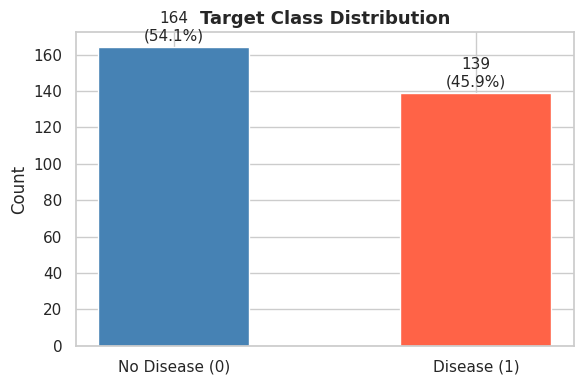


Minority / Majority ratio: 0.848
The dataset is MILDLY imbalanced (≈54 % disease, ≈46 % no-disease).
We will apply SMOTE on the TRAINING split only as a precaution.


In [4]:

df['target'] = (df['target'] > 0).astype(int)

class_counts = df['target'].value_counts().sort_index()
class_pct    = df['target'].value_counts(normalize=True).sort_index() * 100

dist_df = pd.DataFrame({'Count': class_counts, 'Percentage (%)': class_pct.round(2)})
dist_df.index = ['No Disease (0)', 'Disease (1)']

print('Class Distribution:')
display(dist_df)

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['No Disease (0)', 'Disease (1)'], class_counts.values,
              color=['steelblue', 'tomato'], edgecolor='white', width=0.5)
for bar, cnt, pct in zip(bars, class_counts.values, class_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            f'{cnt}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=11)
ax.set_title('Target Class Distribution', fontsize=13, fontweight='bold')
ax.set_ylabel('Count')
plt.tight_layout(); plt.show()

#  Balance decision
ratio = class_counts.min() / class_counts.max()
print(f'\nMinority / Majority ratio: {ratio:.3f}')
print('The dataset is MILDLY imbalanced (≈54 % disease, ≈46 % no-disease).')
print('We will apply SMOTE on the TRAINING split only as a precaution.')

### Pre-4 · Feature encoding and scaling

In [5]:

CAT_COLS  = ['cp', 'restecg', 'slope', 'thal']
CONT_COLS = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']
BIN_COLS  = ['sex', 'fbs', 'exang']

TARGET = 'target'

X = df.drop(columns=[TARGET])
y = df[TARGET]
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)
print(f'Train size: {X_train_raw.shape[0]}  |  Test size: {X_test_raw.shape[0]}')

X_train_enc = pd.get_dummies(X_train_raw, columns=CAT_COLS, drop_first=False)
X_test_enc  = pd.get_dummies(X_test_raw,  columns=CAT_COLS, drop_first=False)

X_test_enc  = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)

scaler = StandardScaler()
X_train_enc[CONT_COLS] = scaler.fit_transform(X_train_enc[CONT_COLS])
X_test_enc[CONT_COLS]  = scaler.transform(X_test_enc[CONT_COLS])

print('\nEncoded + scaled train shape:', X_train_enc.shape)
print('Encoded + scaled test shape :', X_test_enc.shape)
display(X_train_enc.head(3))

Train size: 242  |  Test size: 61

Encoded + scaled train shape: (242, 22)
Encoded + scaled test shape : (61, 22)


,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,ca,cp_0,...,cp_3,restecg_0,restecg_1,restecg_2,slope_0,slope_1,slope_2,thal_1,thal_2,thal_3
180,-0.729485,1,-0.395692,0.458139,0,0.708371,0,-0.445445,-0.689715,False,...,True,False,False,True,False,True,False,False,False,True
208,0.050166,1,-0.054513,0.230598,0,0.222495,0,-0.891627,-0.689715,False,...,False,True,False,False,True,False,False,True,False,False
167,-0.061212,0,0.059213,0.723605,1,0.399178,1,-0.891627,0.445734,False,...,False,False,False,True,True,False,False,True,False,False


### Pre-3 continued · Apply SMOTE to training split only

In [6]:
smote = SMOTE(random_state=SEED)
X_train_res, y_train_res = smote.fit_resample(X_train_enc, y_train)

print('After SMOTE:')
print(pd.Series(y_train_res).value_counts().to_string())
print(f'\nResampled training shape: {X_train_res.shape}')

After SMOTE:
target
1    131
0    131

Resampled training shape: (262, 22)


### Pre-5 · Stratified split already done above (kept as reference)

In [7]:

print('Train target distribution:')
print((y_train.value_counts(normalize=True)*100).round(2).to_string())
print('\nTest target distribution:')
print((y_test.value_counts(normalize=True)*100).round(2).to_string())

Train target distribution:
target
0    54.13
1    45.87

Test target distribution:
target
0    54.1
1    45.9


### Pre-6 · Correlation heatmap

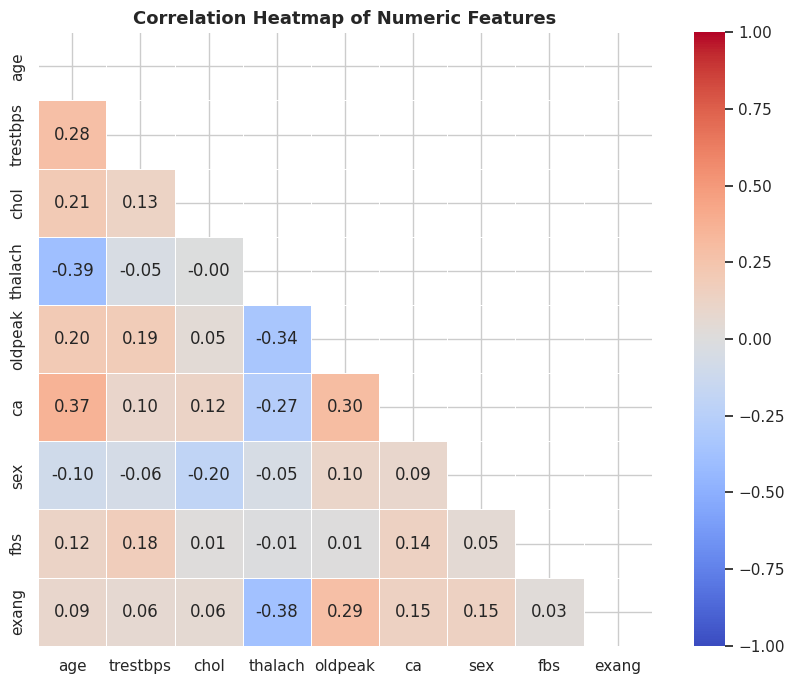

Top 3 feature pairs by absolute correlation:
  age — thalach: -0.394
  thalach — exang: -0.378
  age — ca: 0.365


In [8]:
numeric_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca', 'sex', 'fbs', 'exang']
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', mask=mask,
            square=True, linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title('Correlation Heatmap of Numeric Features', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

corr_unstacked = corr.where(~mask).unstack().dropna()
corr_unstacked = corr_unstacked[corr_unstacked.index.get_level_values(0) !=
                                corr_unstacked.index.get_level_values(1)]
top3 = corr_unstacked.abs().sort_values(ascending=False).head(3)
print('Top 3 feature pairs by absolute correlation:')
for (f1, f2), v in top3.items():
    print(f'  {f1} — {f2}: {corr.loc[f1, f2]:.3f}')




 # PART A — Unsupervised Learning

### Prepare standardised feature matrix (no labels)

In [9]:

X_full_enc = pd.concat([X_train_enc, X_test_enc], axis=0).reset_index(drop=True)
y_full     = pd.concat([y_train,     y_test    ], axis=0).reset_index(drop=True)

X_std = X_full_enc.values
print('Full standardised matrix shape:', X_std.shape)

Full standardised matrix shape: (303, 22)


## A1 · K-Means Clustering

In [10]:

k_range  = range(2, 9)
wcss     = []
sil      = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labels = km.fit_predict(X_std)
    wcss.append(km.inertia_)
    sil.append(silhouette_score(X_std, labels))
    print(f'k={k}  WCSS={km.inertia_:.1f}  Silhouette={sil[-1]:.4f}')

BEST_K = 2

k=2  WCSS=2215.4  Silhouette=0.1778
k=3  WCSS=2022.9  Silhouette=0.1261
k=4  WCSS=1879.0  Silhouette=0.1331
k=5  WCSS=1788.6  Silhouette=0.1274
k=6  WCSS=1711.8  Silhouette=0.1150
k=7  WCSS=1647.5  Silhouette=0.1025
k=8  WCSS=1595.8  Silhouette=0.1008


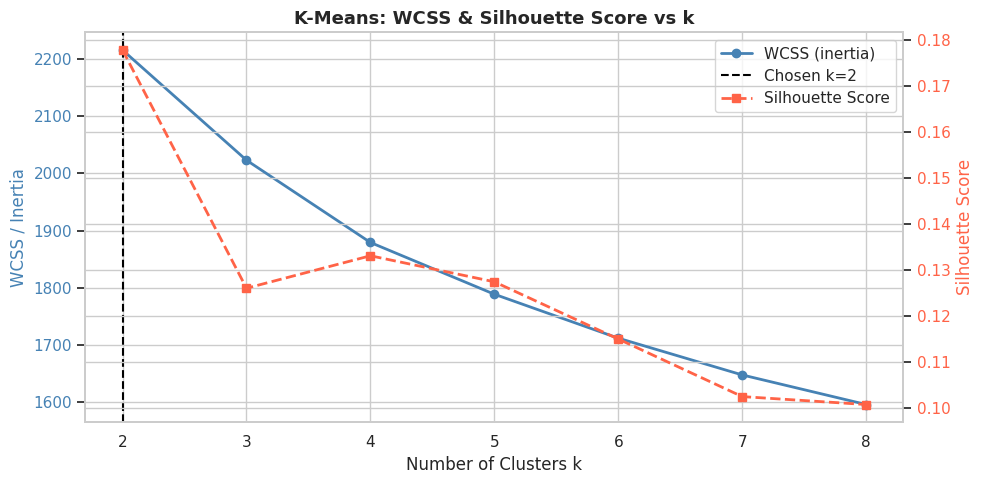

In [11]:

fig, ax1 = plt.subplots(figsize=(10, 5))

ks = list(k_range)
color1, color2 = 'steelblue', 'tomato'

ax1.plot(ks, wcss, 'o-', color=color1, lw=2, label='WCSS (inertia)')
ax1.set_xlabel('Number of Clusters k', fontsize=12)
ax1.set_ylabel('WCSS / Inertia', color=color1, fontsize=12)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.axvline(BEST_K, color='black', ls='--', lw=1.5, label=f'Chosen k={BEST_K}')

ax2 = ax1.twinx()
ax2.plot(ks, sil, 's--', color=color2, lw=2, label='Silhouette Score')
ax2.set_ylabel('Silhouette Score', color=color2, fontsize=12)
ax2.tick_params(axis='y', labelcolor=color2)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
ax1.set_title('K-Means: WCSS & Silhouette Score vs k', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


In [12]:

km_best   = KMeans(n_clusters=BEST_K, random_state=SEED, n_init=10)
km_labels = km_best.fit_predict(X_std)

pca2 = PCA(n_components=2, random_state=SEED)
X_pca2 = pca2.fit_transform(X_std)
print(f'PCA 2D — Explained variance: PC1={pca2.explained_variance_ratio_[0]:.3f}, '
      f'PC2={pca2.explained_variance_ratio_[1]:.3f}')

PCA 2D — Explained variance: PC1=0.274, PC2=0.132


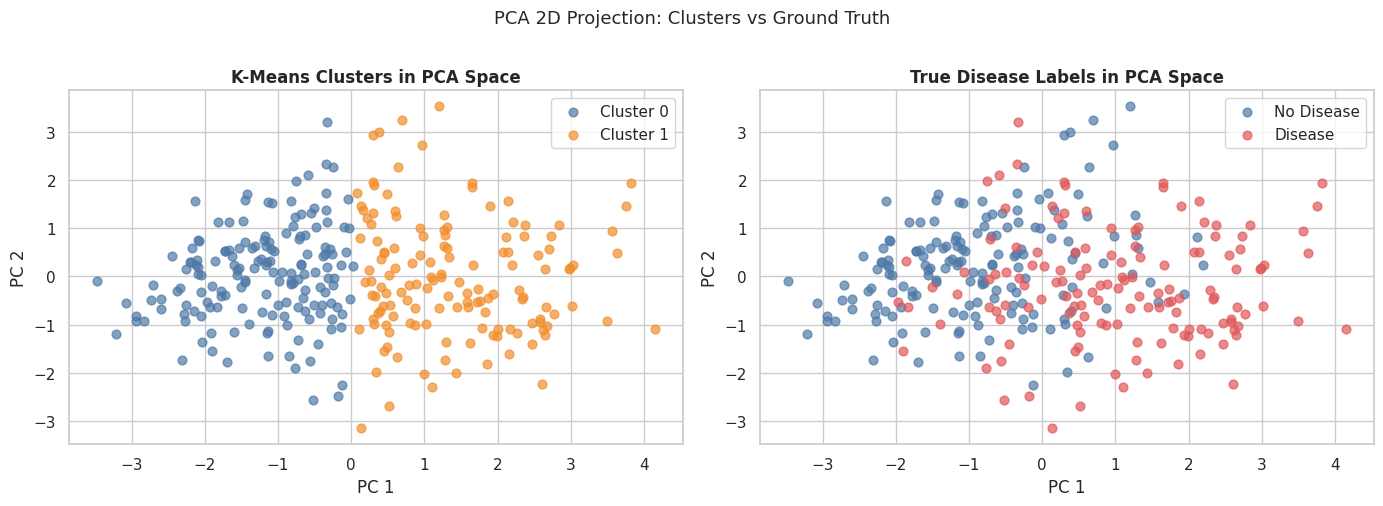

In [13]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

palette_km   = ['#4e79a7', '#f28e2b', '#59a14f', '#e15759', '#76b7b2', '#edc948', '#b07aa1']
palette_true = {0: '#4e79a7', 1: '#e15759'}

for cl in range(BEST_K):
    mask_cl = km_labels == cl
    axes[0].scatter(X_pca2[mask_cl, 0], X_pca2[mask_cl, 1],
                    c=palette_km[cl], label=f'Cluster {cl}', alpha=0.7, s=40)
axes[0].set_title('K-Means Clusters in PCA Space', fontweight='bold')
axes[0].set_xlabel('PC 1'); axes[0].set_ylabel('PC 2')
axes[0].legend()

for lbl, (color, name) in {0: ('#4e79a7', 'No Disease'), 1: ('#e15759', 'Disease')}.items():
    mask_lbl = y_full == lbl
    axes[1].scatter(X_pca2[mask_lbl, 0], X_pca2[mask_lbl, 1],
                    c=color, label=name, alpha=0.7, s=40)
axes[1].set_title('True Disease Labels in PCA Space', fontweight='bold')
axes[1].set_xlabel('PC 1'); axes[1].set_ylabel('PC 2')
axes[1].legend()

plt.suptitle('PCA 2D Projection: Clusters vs Ground Truth', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()



In [14]:

X_orig_full = pd.concat([
    X_train_raw.reset_index(drop=True),
    X_test_raw.reset_index(drop=True)
], axis=0).reset_index(drop=True)

summary_df = X_orig_full[['thalach', 'oldpeak', 'cp']].copy()
summary_df['cluster']  = km_labels
summary_df['disease']  = y_full.values

cluster_summary = summary_df.groupby('cluster').agg(
    size        = ('disease', 'count'),
    disease_pct = ('disease', lambda x: f'{x.mean()*100:.1f}%'),
    mean_thalach= ('thalach',  'mean'),
    mean_oldpeak= ('oldpeak',  'mean'),
    mean_cp     = ('cp',       'mean')
)

print('Cluster Summary (top 3 clinical features):')
display(cluster_summary)


Cluster Summary (top 3 clinical features):


,size,disease_pct,mean_thalach,mean_oldpeak,mean_cp
cluster,,,,,
0,163,20.9%,162.877301,0.485276,1.895706
1,140,75.0%,134.157143,1.685000,2.464286


In [15]:

ari_km = adjusted_rand_score(y_full, km_labels)
print(f'Adjusted Rand Index (K-Means vs True Labels): {ari_km:.4f}')
print('''
Interpretation:
  ARI = 0 corresponds to random clustering; ARI = 1 is perfect agreement.
  A moderate positive ARI (>0.2) indicates that K-Means captures genuine structure
  aligned with the clinical labels, even without using label information during training.
  This supports the hypothesis that heart-disease patients form a distinguishable cluster
  in feature space.
''')

Adjusted Rand Index (K-Means vs True Labels): 0.2942

Interpretation:
  ARI = 0 corresponds to random clustering; ARI = 1 is perfect agreement.
  A moderate positive ARI (>0.2) indicates that K-Means captures genuine structure
  aligned with the clinical labels, even without using label information during training.
  This supports the hypothesis that heart-disease patients form a distinguishable cluster
  in feature space.



## A2 · Hierarchical Clustering [7 Marks]

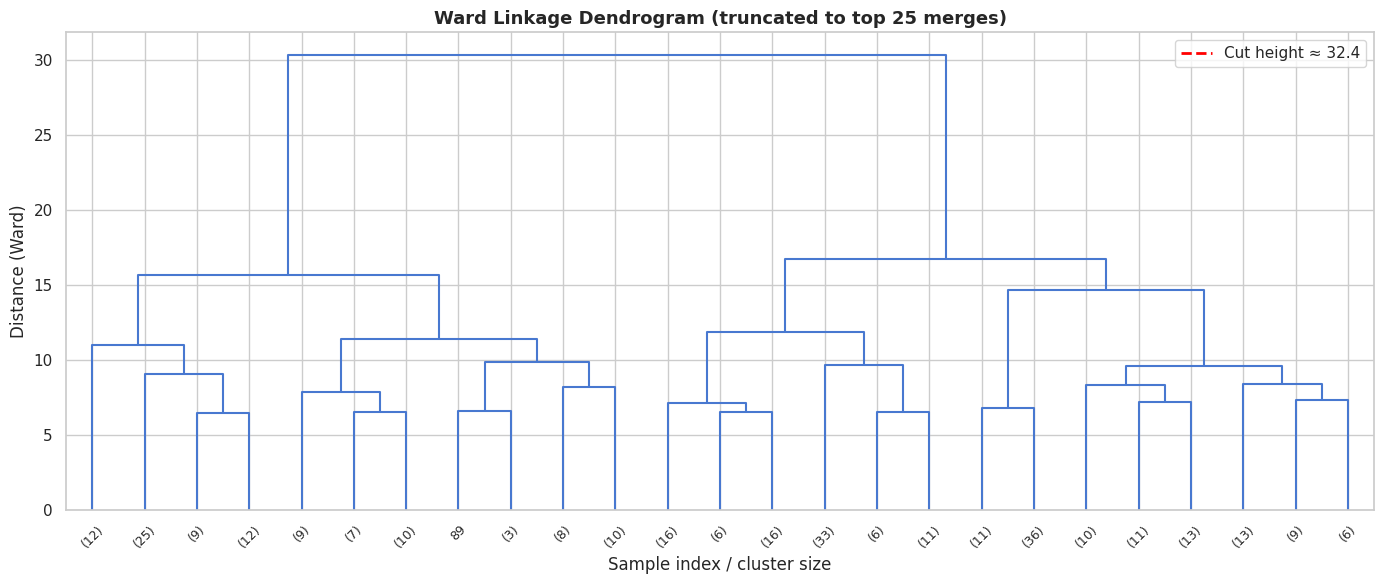

Cut height = 32.38 → 1 clusters


In [16]:

Z = linkage(X_std, method='ward')

fig, ax = plt.subplots(figsize=(14, 6))
dendrogram(Z, truncate_mode='lastp', p=25, ax=ax,
           leaf_rotation=45, leaf_font_size=9, color_threshold=0)

last_merges   = Z[-25:, 2]
acceleration  = np.diff(last_merges)
cut_height    = (Z[-2, 2] + Z[-3, 2])

ax.axhline(y=cut_height, color='red', ls='--', lw=2, label=f'Cut height ≈ {cut_height:.1f}')
ax.set_title('Ward Linkage Dendrogram (truncated to top 25 merges)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Sample index / cluster size')
ax.set_ylabel('Distance (Ward)')
ax.legend()
plt.tight_layout(); plt.show()
hc_labels = fcluster(Z, t=cut_height, criterion='distance') - 1
n_hc      = len(np.unique(hc_labels))
print(f'Cut height = {cut_height:.2f} → {n_hc} clusters')

In [17]:

crosstab = pd.crosstab(hc_labels, y_full.values,
                       rownames=['HC Cluster'], colnames=['True Label'])
crosstab.columns = ['No Disease (0)', 'Disease (1)']
print('Hierarchical Clustering × True Label crosstab:')
display(crosstab)

Hierarchical Clustering × True Label crosstab:


,No Disease (0),Disease (1)
HC Cluster,,
0,164,139


## A3 · Dimensionality Reduction [5 Marks]

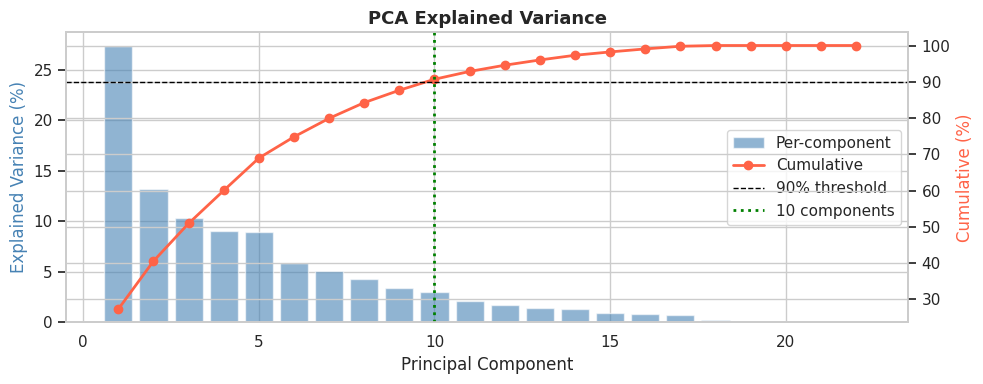

Components needed for 90% explained variance: 10


In [18]:

pca_full = PCA(random_state=SEED)
pca_full.fit(X_std)

evr   = pca_full.explained_variance_ratio_
cumev = np.cumsum(evr)
n90   = np.argmax(cumev >= 0.90) + 1

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(1, len(evr)+1), evr * 100, alpha=0.6, color='steelblue', label='Per-component')
ax2 = ax.twinx()
ax2.plot(range(1, len(evr)+1), cumev * 100, 'o-', color='tomato', lw=2, label='Cumulative')
ax2.axhline(90, color='black', ls='--', lw=1, label='90% threshold')
ax2.axvline(n90, color='green', ls=':', lw=2, label=f'{n90} components')
ax.set_xlabel('Principal Component'); ax.set_ylabel('Explained Variance (%)', color='steelblue')
ax2.set_ylabel('Cumulative (%)', color='tomato')
ax.set_title('PCA Explained Variance', fontsize=13, fontweight='bold')
lines1, labs1 = ax.get_legend_handles_labels()
lines2, labs2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labs1 + labs2, loc='center right')
plt.tight_layout(); plt.show()

print(f'Components needed for 90% explained variance: {n90}')

Running t-SNE (may take 30–60 s)...


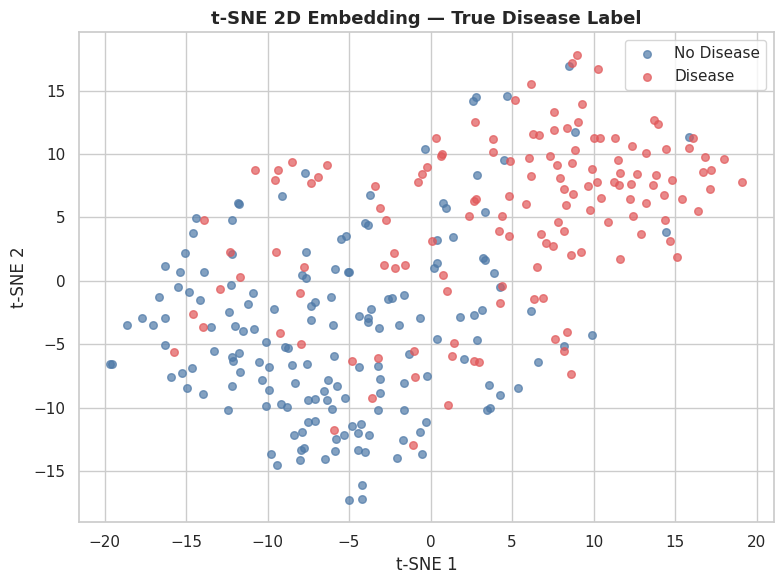

In [19]:

print('Running t-SNE (may take 30–60 s)...')
tsne  = TSNE(n_components=2, perplexity=30, random_state=SEED, n_iter=1000)
X_tsne = tsne.fit_transform(X_std)

fig, ax = plt.subplots(figsize=(8, 6))
for lbl, (color, name) in {0: ('#4e79a7', 'No Disease'), 1: ('#e15759', 'Disease')}.items():
    mask = y_full == lbl
    ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1], c=color, label=name, alpha=0.7, s=30)
ax.set_title('t-SNE 2D Embedding — True Disease Label', fontsize=13, fontweight='bold')
ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')
ax.legend()
plt.tight_layout(); plt.show()



#  PART B — Bagging & Boosting

## B1 · Random Forest

In [20]:

rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth'   : [None, 5, 10]
}

rf_base = RandomForestClassifier(oob_score=True, random_state=SEED, n_jobs=-1)

rf_gs = GridSearchCV(
    rf_base, rf_param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    scoring='f1', n_jobs=-1, verbose=0
)
rf_gs.fit(X_train_res, y_train_res)

print(f'Best params : {rf_gs.best_params_}')
print(f'Best CV F1  : {rf_gs.best_score_:.4f}')

Best params : {'max_depth': 10, 'n_estimators': 200}
Best CV F1  : 0.8323


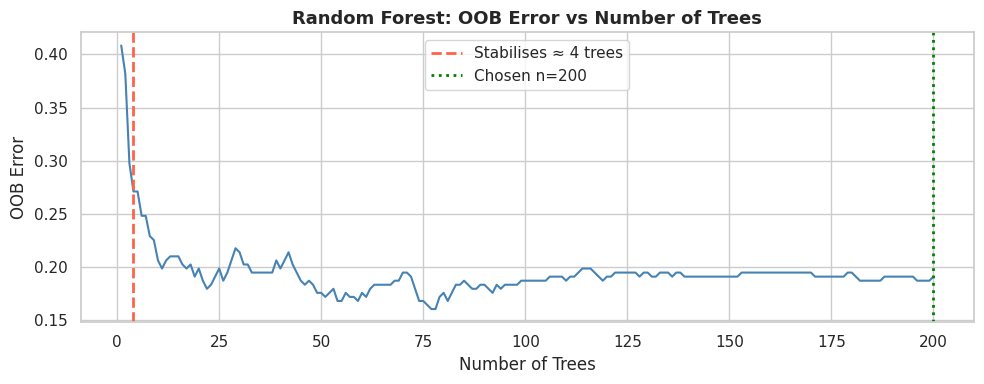

OOB error stabilises at ≈ 4 trees.


In [21]:

oob_errors = []
n_est_range = range(1, 201)

for n in n_est_range:
    rf_tmp = RandomForestClassifier(
        n_estimators=n, max_depth=rf_gs.best_params_['max_depth'],
        oob_score=True, random_state=SEED, n_jobs=-1
    )
    rf_tmp.fit(X_train_res, y_train_res)
    oob_errors.append(1 - rf_tmp.oob_score_)


diffs   = np.abs(np.diff(oob_errors))
stab_n  = np.argmax(diffs < 0.001) + 1

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(list(n_est_range), oob_errors, color='steelblue', lw=1.5)
ax.axvline(stab_n, color='tomato', ls='--', lw=2, label=f'Stabilises ≈ {stab_n} trees')
ax.axvline(rf_gs.best_params_['n_estimators'], color='green', ls=':',
           lw=2, label=f"Chosen n={rf_gs.best_params_['n_estimators']}")
ax.set_xlabel('Number of Trees'); ax.set_ylabel('OOB Error')
ax.set_title('Random Forest: OOB Error vs Number of Trees', fontsize=13, fontweight='bold')
ax.legend(); plt.tight_layout(); plt.show()

print(f'OOB error stabilises at ≈ {stab_n} trees.')

In [22]:

rf_best = RandomForestClassifier(
    **rf_gs.best_params_, oob_score=True, random_state=SEED, n_jobs=-1
)
t0 = time.time()
rf_best.fit(X_train_res, y_train_res)
rf_train_time = time.time() - t0

y_pred_rf  = rf_best.predict(X_test_enc)
y_prob_rf  = rf_best.predict_proba(X_test_enc)[:, 1]

rf_acc  = accuracy_score(y_test, y_pred_rf)
rf_f1   = f1_score(y_test, y_pred_rf, average='macro')
rf_auc  = roc_auc_score(y_test, y_prob_rf)
rf_rec  = f1_score(y_test, y_pred_rf, average=None)[1]
print('Random Forest — Test Metrics')
print(classification_report(y_test, y_pred_rf, target_names=['No Disease', 'Disease']))
print(f'AUC-ROC : {rf_auc:.4f}  |  Train time: {rf_train_time:.2f}s')

Random Forest — Test Metrics
              precision    recall  f1-score   support

  No Disease       0.97      0.85      0.90        33
     Disease       0.84      0.96      0.90        28

    accuracy                           0.90        61
   macro avg       0.90      0.91      0.90        61
weighted avg       0.91      0.90      0.90        61

AUC-ROC : 0.9443  |  Train time: 0.56s


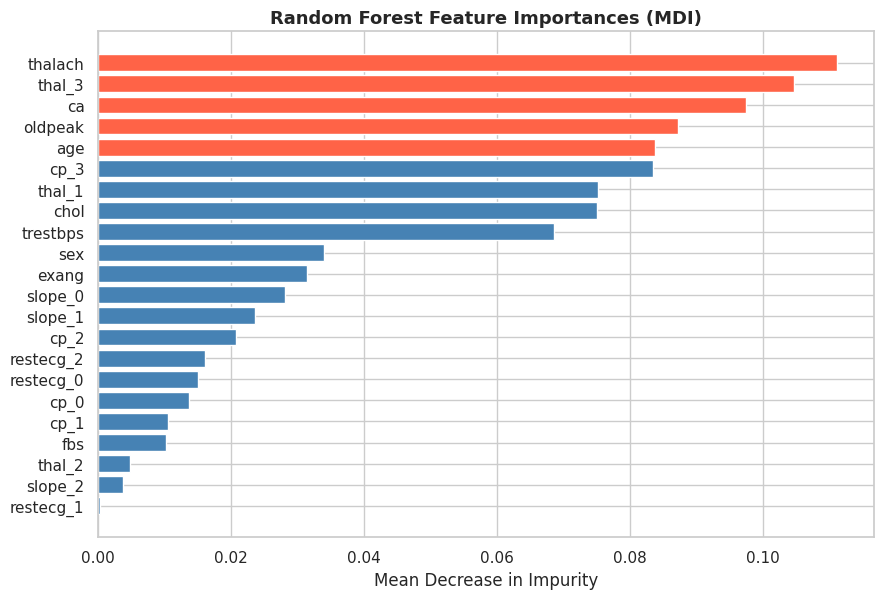

Top 5 features:
  thalach: 0.1112
  thal_3: 0.1047
  ca: 0.0975
  oldpeak: 0.0873
  age: 0.0839


In [23]:

feat_names = X_train_enc.columns.tolist()
importances = rf_best.feature_importances_
fi_df = pd.DataFrame({'feature': feat_names, 'importance': importances})
fi_df = fi_df.sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(9, max(5, len(feat_names)*0.28)))
colors = ['tomato' if i >= len(feat_names)-5 else 'steelblue'
          for i in range(len(feat_names))]
ax.barh(fi_df['feature'], fi_df['importance'], color=colors, edgecolor='white')
ax.set_title('Random Forest Feature Importances (MDI)', fontsize=13, fontweight='bold')
ax.set_xlabel('Mean Decrease in Impurity')
plt.tight_layout(); plt.show()

top5 = fi_df.nlargest(5, 'importance')
print('Top 5 features:')
for _, row in top5.iterrows():
    print(f"  {row['feature']}: {row['importance']:.4f}")



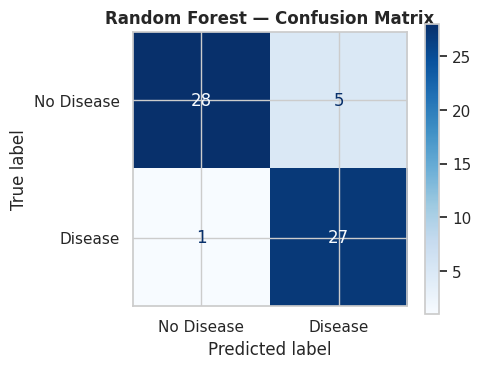

In [24]:

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf, display_labels=['No Disease', 'Disease'],
    cmap='Blues', ax=ax
)
ax.set_title('Random Forest — Confusion Matrix', fontweight='bold')
plt.tight_layout(); plt.show()


## B2 · XGBoost Gradient Boosting

In [25]:

xgb_param_grid = {
    'learning_rate': [0.01, 0.1, 0.3],
    'max_depth'    : [3, 5, 7]
}

xgb_base = xgb.XGBClassifier(
    n_estimators=500, use_label_encoder=False,
    eval_metric='logloss', random_state=SEED, n_jobs=-1
)

xgb_gs = GridSearchCV(
    xgb_base, xgb_param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    scoring='f1', n_jobs=-1, verbose=0
)
xgb_gs.fit(X_train_res, y_train_res)

print(f'Best XGBoost params : {xgb_gs.best_params_}')
print(f'Best CV F1          : {xgb_gs.best_score_:.4f}')

Best XGBoost params : {'learning_rate': 0.1, 'max_depth': 3}
Best CV F1          : 0.8303


In [36]:
import time
import xgboost as xgb
from sklearn.model_selection import train_test_split

# Split data
Xtr, Xval, ytr, yval = train_test_split(
    X_train_res,
    y_train_res,
    test_size=0.2,
    random_state=SEED,
    stratify=y_train_res
)

# Define model WITH early stopping here
xgb_final = xgb.XGBClassifier(
    n_estimators=1000,
    learning_rate=xgb_gs.best_params_['learning_rate'],
    max_depth=xgb_gs.best_params_['max_depth'],
    eval_metric='logloss',
    early_stopping_rounds=50,
    random_state=SEED,
    n_jobs=-1
)

# Train
t0 = time.time()

xgb_final.fit(
    Xtr, ytr,
    eval_set=[(Xval, yval)],
    verbose=True
)

xgb_train_time = time.time() - t0

# Get best iteration safely
booster = xgb_final.get_booster()
opt_round = booster.best_iteration
best_score = booster.best_score

print(f'Optimal boosting round (early stopping): {opt_round}')
print(f'Best validation score: {best_score}')
print(f'Training time: {xgb_train_time:.2f}s')


[0]	validation_0-logloss:0.64805
[1]	validation_0-logloss:0.61042
[2]	validation_0-logloss:0.57818
[3]	validation_0-logloss:0.55176
[4]	validation_0-logloss:0.52420
[5]	validation_0-logloss:0.50430
[6]	validation_0-logloss:0.48573
[7]	validation_0-logloss:0.46980
[8]	validation_0-logloss:0.45817
[9]	validation_0-logloss:0.44147
[10]	validation_0-logloss:0.42781
[11]	validation_0-logloss:0.42040
[12]	validation_0-logloss:0.41150
[13]	validation_0-logloss:0.40835
[14]	validation_0-logloss:0.40137
[15]	validation_0-logloss:0.39398
[16]	validation_0-logloss:0.39213
[17]	validation_0-logloss:0.38595
[18]	validation_0-logloss:0.38362
[19]	validation_0-logloss:0.37999
[20]	validation_0-logloss:0.37513
[21]	validation_0-logloss:0.37028
[22]	validation_0-logloss:0.36363
[23]	validation_0-logloss:0.36053
[24]	validation_0-logloss:0.36043
[25]	validation_0-logloss:0.35665
[26]	validation_0-logloss:0.35706
[27]	validation_0-logloss:0.35378
[28]	validation_0-logloss:0.35205
[29]	validation_0-loglos

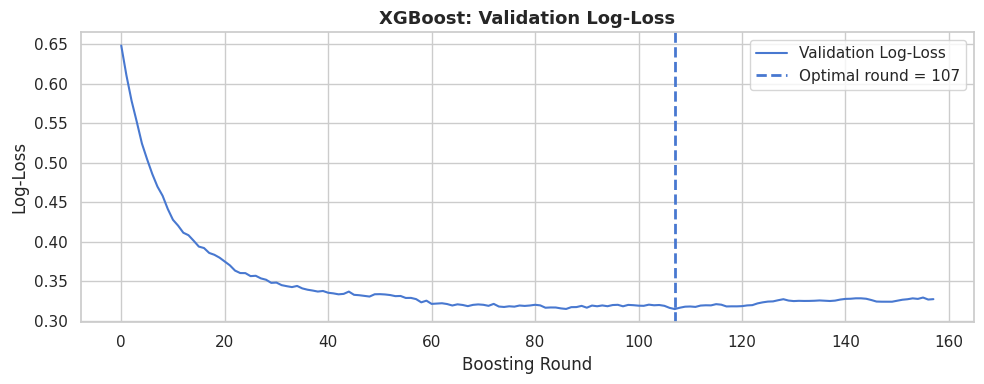

In [38]:
evals_result = xgb_final.evals_result()

val_logloss = evals_result['validation_0']['logloss']

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(val_logloss, label='Validation Log-Loss', lw=1.5)
ax.axvline(opt_round, ls='--', lw=2, label=f'Optimal round = {opt_round}')

ax.set_xlabel('Boosting Round')
ax.set_ylabel('Log-Loss')
ax.set_title('XGBoost: Validation Log-Loss', fontsize=13, fontweight='bold')
ax.legend()

plt.tight_layout()
plt.show()

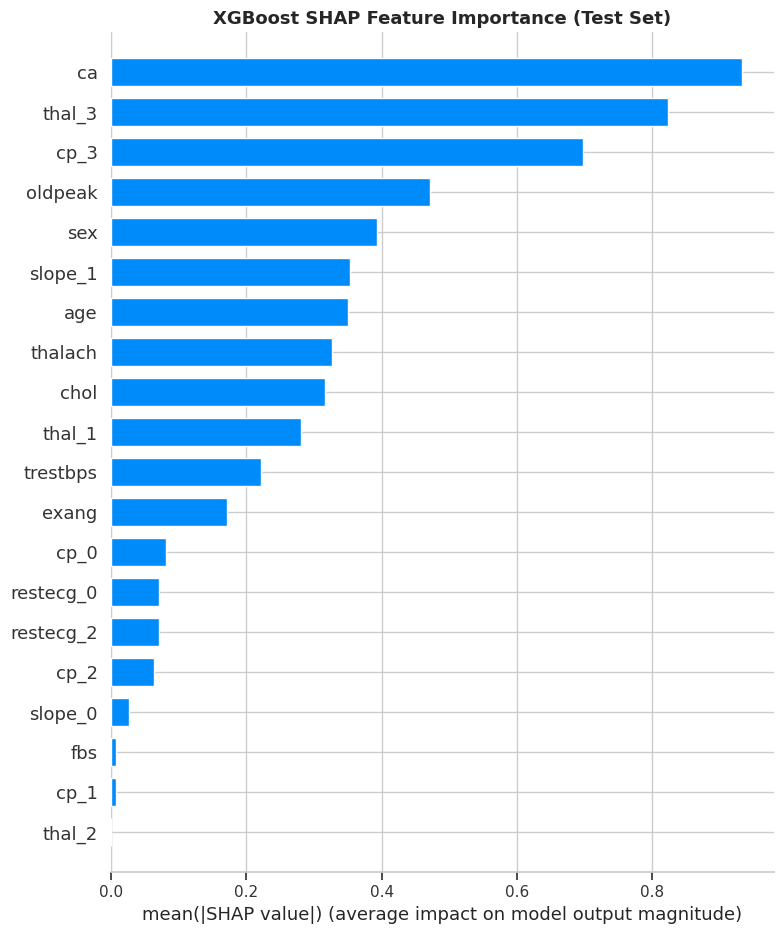

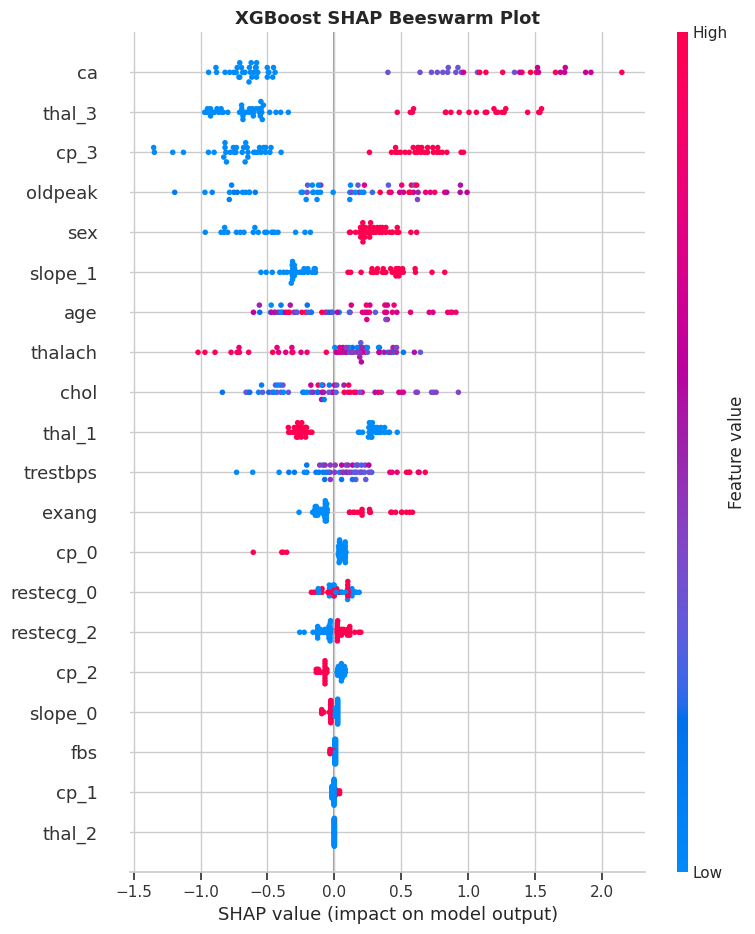

In [39]:

explainer_xgb = shap.TreeExplainer(xgb_final)
shap_values   = explainer_xgb.shap_values(X_test_enc)

fig, ax = plt.subplots(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_enc, plot_type='bar',
                  feature_names=feat_names, show=False)
plt.title('XGBoost SHAP Feature Importance (Test Set)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

fig2, ax2 = plt.subplots(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_enc, feature_names=feat_names, show=False)
plt.title('XGBoost SHAP Beeswarm Plot', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

XGBoost — Test Metrics
              precision    recall  f1-score   support

  No Disease       0.96      0.82      0.89        33
     Disease       0.82      0.96      0.89        28

    accuracy                           0.89        61
   macro avg       0.89      0.89      0.89        61
weighted avg       0.90      0.89      0.89        61

AUC-ROC : 0.9481


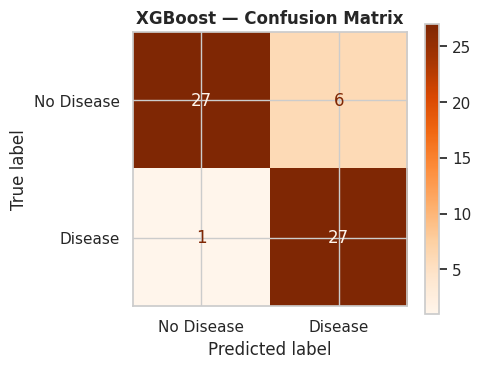

In [40]:

y_pred_xgb = xgb_final.predict(X_test_enc)
y_prob_xgb = xgb_final.predict_proba(X_test_enc)[:, 1]

xgb_acc = accuracy_score(y_test, y_pred_xgb)
xgb_f1  = f1_score(y_test, y_pred_xgb, average='macro')
xgb_auc = roc_auc_score(y_test, y_prob_xgb)
xgb_rec = f1_score(y_test, y_pred_xgb, average=None)[1]

print('XGBoost — Test Metrics')
print(classification_report(y_test, y_pred_xgb, target_names=['No Disease', 'Disease']))
print(f'AUC-ROC : {xgb_auc:.4f}')

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_xgb, display_labels=['No Disease', 'Disease'],
    cmap='Oranges', ax=ax
)
ax.set_title('XGBoost — Confusion Matrix', fontweight='bold')
plt.tight_layout(); plt.show()

## B3 · Ensemble Comparison & ROC

In [41]:

comparison = pd.DataFrame([
    {'Classifier': 'Random Forest',  'Accuracy': rf_acc,  'Macro F1': rf_f1,
     'AUC-ROC': rf_auc,  'Recall (Disease)': rf_rec,  'Train Time(s)': rf_train_time},
    {'Classifier': 'XGBoost',        'Accuracy': xgb_acc, 'Macro F1': xgb_f1,
     'AUC-ROC': xgb_auc, 'Recall (Disease)': xgb_rec, 'Train Time(s)': xgb_train_time},
])
comparison = comparison.round(4)
print('Ensemble Comparison Table:')
display(comparison)

Ensemble Comparison Table:


,Classifier,Accuracy,Macro F1,AUC-ROC,Recall (Disease),Train Time(s)
0,Random Forest,0.9016,0.9016,0.9443,0.9000,0.5634
1,XGBoost,0.8852,0.8852,0.9481,0.8852,0.9308


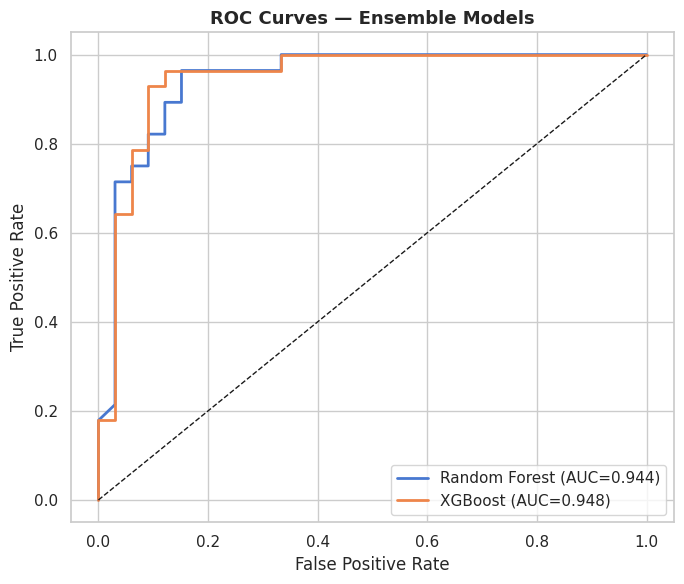

In [42]:

fig, ax = plt.subplots(figsize=(7, 6))

for name, y_prob in [('Random Forest', y_prob_rf), ('XGBoost', y_prob_xgb)]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_val = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, lw=2, label=f'{name} (AUC={auc_val:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Ensemble Models', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout(); plt.show()




#  PART C — Artificial Neural Networks

## C1 · Single-Layer Perceptron

In [43]:

def build_slp(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(1, activation='sigmoid')
    ], name='SLP')
    model.compile(
        optimizer=keras.optimizers.SGD(learning_rate=0.01),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

slp = build_slp(X_train_res.shape[1])
slp.summary()

slp_history = slp.fit(
    X_train_res, y_train_res,
    epochs=100, batch_size=32,
    verbose=0
)

Model: "SLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │            23 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23 (92.00 B)

 Trainable params: 23 (92.00 B)

 Non-trainable params: 0 (0.00 B)

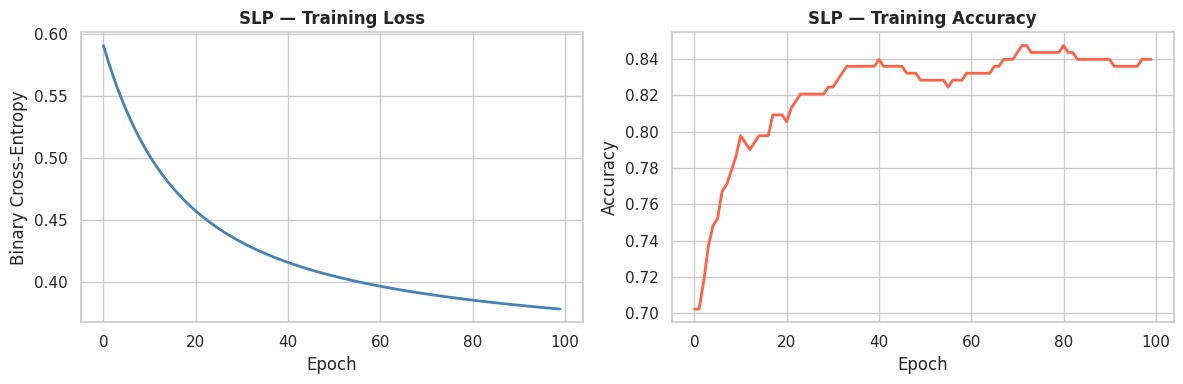

In [44]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(slp_history.history['loss'], color='steelblue', lw=2)
axes[0].set_title('SLP — Training Loss', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Binary Cross-Entropy')

axes[1].plot(slp_history.history['accuracy'], color='tomato', lw=2)
axes[1].set_title('SLP — Training Accuracy', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')

plt.tight_layout(); plt.show()

In [45]:

weights_slp = slp.layers[0].get_weights()[0].flatten()
weight_df   = pd.DataFrame({'feature': feat_names, 'abs_weight': np.abs(weights_slp)})
weight_df   = weight_df.sort_values('abs_weight', ascending=False)

print('Top 3 features by absolute SLP weight:')
display(weight_df.head(3))

print('\nTop 5 RF features (from B1):')
display(fi_df.nlargest(5, 'importance')[['feature', 'importance']])



Top 3 features by absolute SLP weight:


,feature,abs_weight
8,ca,0.782497
19,thal_1,0.741255
12,cp_3,0.666326



Top 5 RF features (from B1):


,feature,importance
5,thalach,0.111200
21,thal_3,0.104704
8,ca,0.097508
7,oldpeak,0.087259
0,age,0.083889


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
SLP — Test Metrics
              precision    recall  f1-score   support

  No Disease       0.93      0.85      0.89        33
     Disease       0.84      0.93      0.88        28

    accuracy                           0.89        61
   macro avg       0.89      0.89      0.89        61
weighted avg       0.89      0.89      0.89        61

AUC-ROC : 0.9589


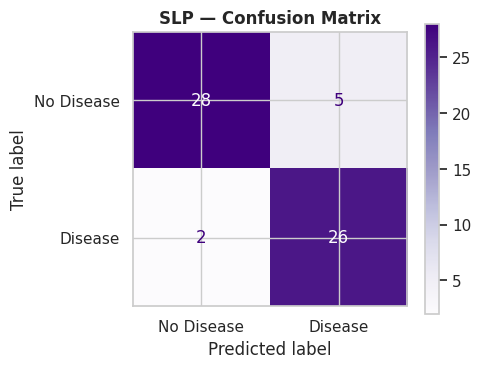

In [46]:

y_prob_slp = slp.predict(X_test_enc).flatten()
y_pred_slp = (y_prob_slp >= 0.5).astype(int)

slp_acc = accuracy_score(y_test, y_pred_slp)
slp_f1  = f1_score(y_test, y_pred_slp, average='macro')
slp_auc = roc_auc_score(y_test, y_prob_slp)

print('SLP — Test Metrics')
print(classification_report(y_test, y_pred_slp, target_names=['No Disease', 'Disease']))
print(f'AUC-ROC : {slp_auc:.4f}')

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_slp, display_labels=['No Disease', 'Disease'],
    cmap='Purples', ax=ax
)
ax.set_title('SLP — Confusion Matrix', fontweight='bold')
plt.tight_layout(); plt.show()



## C2 · Multi-Layer Perceptron

In [47]:

def build_mlp(layer_sizes, dropout_rate=0.3, l2_reg=0.001, input_dim=None, name='MLP'):
    model = keras.Sequential(name=name)
    model.add(layers.Input(shape=(input_dim,)))
    for size in layer_sizes:
        model.add(layers.Dense(size, activation='relu',
                               kernel_regularizer=regularizers.l2(l2_reg)))
        model.add(layers.BatchNormalization())
        model.add(layers.Dropout(dropout_rate))
    model.add(layers.Dense(1, activation='sigmoid'))
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model


ARCHITECTURES = [
    ('Small',  [32]),
    ('Medium', [64, 32]),
    ('Large',  [128, 64, 32]),
]

mlp_results = []
input_dim   = X_train_res.shape[1]

# Validation split from training data
Xtr_mlp, Xval_mlp, ytr_mlp, yval_mlp = train_test_split(
    X_train_res, y_train_res, test_size=0.15, random_state=SEED, stratify=y_train_res
)

es_cb = callbacks.EarlyStopping(monitor='val_loss', patience=10,
                                 restore_best_weights=True)

for arch_name, layers_sizes in ARCHITECTURES:
    m = build_mlp(layers_sizes, input_dim=input_dim, name=arch_name)
    t0 = time.time()
    hist = m.fit(
        Xtr_mlp, ytr_mlp,
        validation_data=(Xval_mlp, yval_mlp),
        epochs=200, batch_size=32,
        callbacks=[es_cb], verbose=0
    )
    elapsed = time.time() - t0
    y_val_pred = (m.predict(Xval_mlp).flatten() >= 0.5).astype(int)
    val_f1     = f1_score(yval_mlp, y_val_pred, average='macro')
    mlp_results.append({'Architecture': arch_name, 'Layers': str(layers_sizes),
                        'Val F1': round(val_f1, 4), 'Train Time(s)': round(elapsed, 2)})
    print(f'{arch_name}: Val F1 = {val_f1:.4f}, time = {elapsed:.2f}s')

print()
display(pd.DataFrame(mlp_results))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step
Small: Val F1 = 0.7749, time = 12.71s


1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
Medium: Val F1 = 0.4357, time = 6.94s
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
Large: Val F1 = 0.6992, time = 4.59s



,Architecture,Layers,Val F1,Train Time(s)
0,Small,[32],0.7749,12.71
1,Medium,"[64, 32]",0.4357,6.94
2,Large,"[128, 64, 32]",0.6992,4.59


In [48]:

print('Training final MLP (Medium architecture)...')

mlp_final = build_mlp([64, 32], dropout_rate=0.3, l2_reg=0.001,
                       input_dim=input_dim, name='MLP_Final')
mlp_final.summary()

es_final = callbacks.EarlyStopping(monitor='val_loss', patience=10,
                                    restore_best_weights=True, verbose=1)

t0 = time.time()
mlp_hist = mlp_final.fit(
    Xtr_mlp, ytr_mlp,
    validation_data=(Xval_mlp, yval_mlp),
    epochs=300, batch_size=32,
    callbacks=[es_final], verbose=0
)
mlp_train_time = time.time() - t0
print(f'Training finished in {mlp_train_time:.2f}s')

Training final MLP (Medium architecture)...


Model: "MLP_Final"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 64)             │         1,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,969 (15.50 KB)

 Trainable params: 3,777 (14.75 KB)

 Non-trainable params: 192 (768.00 B)

Epoch 73: early stopping
Restoring model weights from the end of the best epoch: 63.
Training finished in 10.71s


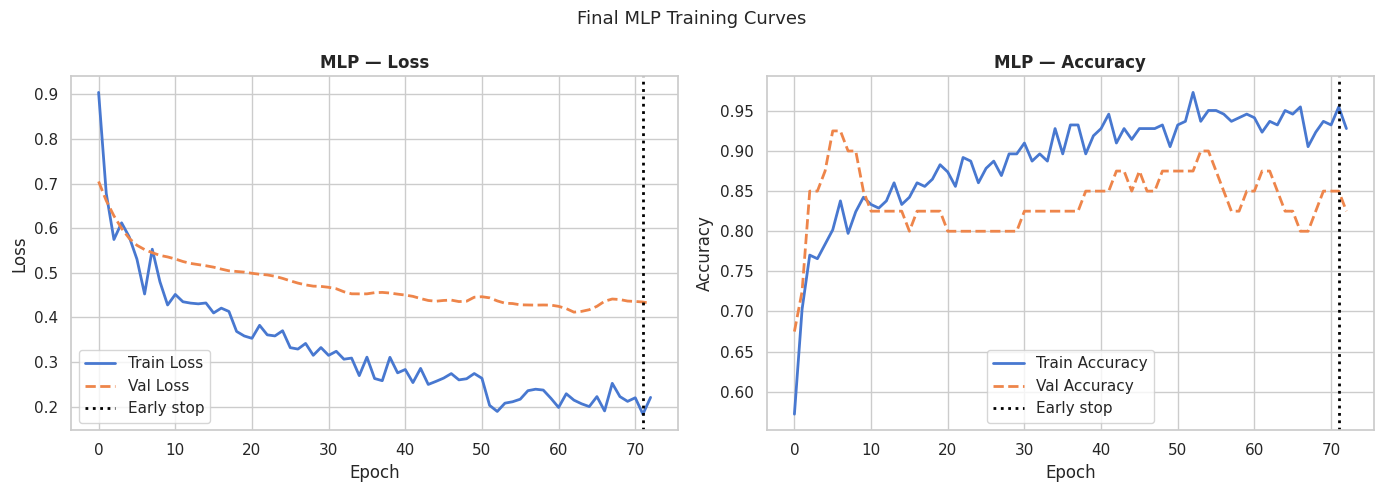

In [49]:

stopped_epoch = es_final.stopped_epoch if es_final.stopped_epoch > 0 else len(mlp_hist.history['loss'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, metric, title in zip(axes, ['loss', 'accuracy'], ['Loss', 'Accuracy']):
    ax.plot(mlp_hist.history[metric],          label=f'Train {title}', lw=2)
    ax.plot(mlp_hist.history[f'val_{metric}'], label=f'Val {title}',   lw=2, ls='--')
    ax.axvline(stopped_epoch - 1, color='black', ls=':', lw=2, label='Early stop')
    ax.set_title(f'MLP — {title}', fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel(title)
    ax.legend()
plt.suptitle('Final MLP Training Curves', fontsize=13)
plt.tight_layout(); plt.show()

In [50]:

from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_acc_scores, cv_f1_scores = [], []

for fold, (tr_idx, vl_idx) in enumerate(skf.split(X_train_res, y_train_res)):
    Xf_tr, Xf_vl = X_train_res.iloc[tr_idx], X_train_res.iloc[vl_idx]
    yf_tr, yf_vl = y_train_res.iloc[tr_idx], y_train_res.iloc[vl_idx]

    m_cv = build_mlp([64, 32], dropout_rate=0.3, l2_reg=0.001, input_dim=input_dim)
    es_cv = callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    m_cv.fit(Xf_tr, yf_tr, validation_data=(Xf_vl, yf_vl),
             epochs=200, batch_size=32, callbacks=[es_cv], verbose=0)

    y_cv_pred = (m_cv.predict(Xf_vl).flatten() >= 0.5).astype(int)
    cv_acc_scores.append(accuracy_score(yf_vl, y_cv_pred))
    cv_f1_scores.append(f1_score(yf_vl, y_cv_pred, average='macro'))
    print(f'Fold {fold+1}: Acc={cv_acc_scores[-1]:.4f}  F1={cv_f1_scores[-1]:.4f}')

print(f'\nCV Accuracy: {np.mean(cv_acc_scores):.4f} ± {np.std(cv_acc_scores):.4f}')
print(f'CV F1      : {np.mean(cv_f1_scores):.4f} ± {np.std(cv_f1_scores):.4f}')

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
Fold 1: Acc=0.8302  F1=0.8292
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step
Fold 2: Acc=0.8491  F1=0.8490
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
Fold 3: Acc=0.8269  F1=0.8253
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
Fold 4: Acc=0.8269  F1=0.8263
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
Fold 5: Acc=0.8269  F1=0.8269

CV Accuracy: 0.8320 ± 0.0086
CV F1      : 0.8313 ± 0.0089


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
MLP — Test Metrics
              precision    recall  f1-score   support

  No Disease       1.00      0.79      0.88        33
     Disease       0.80      1.00      0.89        28

    accuracy                           0.89        61
   macro avg       0.90      0.89      0.89        61
weighted avg       0.91      0.89      0.88        61

AUC-ROC : 0.9567


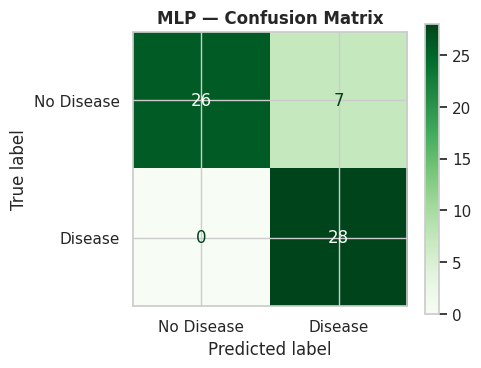

In [51]:

y_prob_mlp = mlp_final.predict(X_test_enc).flatten()
y_pred_mlp = (y_prob_mlp >= 0.5).astype(int)

mlp_acc = accuracy_score(y_test, y_pred_mlp)
mlp_f1  = f1_score(y_test, y_pred_mlp, average='macro')
mlp_auc = roc_auc_score(y_test, y_prob_mlp)
mlp_rec = f1_score(y_test, y_pred_mlp, average=None)[1]

print('MLP — Test Metrics')
print(classification_report(y_test, y_pred_mlp, target_names=['No Disease', 'Disease']))
print(f'AUC-ROC : {mlp_auc:.4f}')

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_mlp, display_labels=['No Disease', 'Disease'],
    cmap='Greens', ax=ax
)
ax.set_title('MLP — Confusion Matrix', fontweight='bold')
plt.tight_layout(); plt.show()


## C3 · Ablation Study

In [52]:
def build_ablation(variant, input_dim):
    """Build ablation variants."""
    model = keras.Sequential()
    model.add(layers.Input(shape=(input_dim,)))

    layer_sizes = [64, 32]
    for size in layer_sizes:
        if variant == 'B':
            model.add(layers.Dense(size, activation='sigmoid',
                                   kernel_regularizer=regularizers.l2(0.001)))
        else:
            model.add(layers.Dense(size, activation='relu',
                                   kernel_regularizer=regularizers.l2(0.001)))
        model.add(layers.BatchNormalization())
        if variant != 'A':
            model.add(layers.Dropout(0.3))

    model.add(layers.Dense(1, activation='sigmoid'))
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model


ablation_results = []

y_prob_best = mlp_final.predict(X_test_enc).flatten()
y_pred_best = (y_prob_best >= 0.5).astype(int)
ablation_results.append({
    'Variant': 'Best MLP (baseline)',
    'Test F1': round(f1_score(y_test, y_pred_best, average='macro'), 4),
    'Val Loss (final)': round(min(mlp_hist.history['val_loss']), 4)
})

for variant, desc, use_es in [
    ('A', 'No Dropout',      True),
    ('B', 'Sigmoid activn',  True),
    ('C', 'No Early Stop',   False),
]:
    m_abl = build_ablation(variant, input_dim)
    abl_callbacks = [callbacks.EarlyStopping(monitor='val_loss', patience=10,
                                              restore_best_weights=True)] if use_es else []
    epochs = 200 if use_es else 150
    h = m_abl.fit(Xtr_mlp, ytr_mlp, validation_data=(Xval_mlp, yval_mlp),
                  epochs=epochs, batch_size=32, callbacks=abl_callbacks, verbose=0)

    y_p = (m_abl.predict(X_test_enc).flatten() >= 0.5).astype(int)
    ablation_results.append({
        'Variant': f'Variant {variant}: {desc}',
        'Test F1': round(f1_score(y_test, y_p, average='macro'), 4),
        'Val Loss (final)': round(min(h.history['val_loss']), 4)
    })
    print(f'Variant {variant} ({desc}): F1 = {ablation_results[-1]["Test F1"]}')

print()
abl_df = pd.DataFrame(ablation_results)
display(abl_df)



2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
Variant A (No Dropout): F1 = 0.8523
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
Variant B (Sigmoid activn): F1 = 0.8688
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
Variant C (No Early Stop): F1 = 0.8851



,Variant,Test F1,Val Loss (final)
0,Best MLP (baseline),0.8851,0.4120
1,Variant A: No Dropout,0.8523,0.3898
2,Variant B: Sigmoid activn,0.8688,0.3795
3,Variant C: No Early Stop,0.8851,0.4321



#  PART D — CNN on MNIST

## D1 · Data Preparation & MLP Baseline

In [53]:

(X_mnist_train_full, y_mnist_train_full), (X_mnist_test_full, y_mnist_test_full) = mnist.load_data()

# Subset as specified
X_mnist_train = X_mnist_train_full[:12000]
y_mnist_train = y_mnist_train_full[:12000]
X_mnist_test  = X_mnist_test_full[:2000]
y_mnist_test  = y_mnist_test_full[:2000]

# Normalise to [0, 1]
X_mnist_train = X_mnist_train.astype('float32') / 255.0
X_mnist_test  = X_mnist_test.astype('float32')  / 255.0

# Reshape for CNN: (N, 28, 28, 1)
X_mnist_train_cnn = X_mnist_train[..., np.newaxis]
X_mnist_test_cnn  = X_mnist_test [..., np.newaxis]

# One-hot labels for CNN
y_mnist_train_oh = keras.utils.to_categorical(y_mnist_train, 10)
y_mnist_test_oh  = keras.utils.to_categorical(y_mnist_test,  10)

print(f'Train: {X_mnist_train_cnn.shape}, labels: {y_mnist_train.shape}')
print(f'Test : {X_mnist_test_cnn.shape},  labels: {y_mnist_test.shape}')

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train: (12000, 28, 28, 1), labels: (12000,)
Test : (2000, 28, 28, 1),  labels: (2000,)


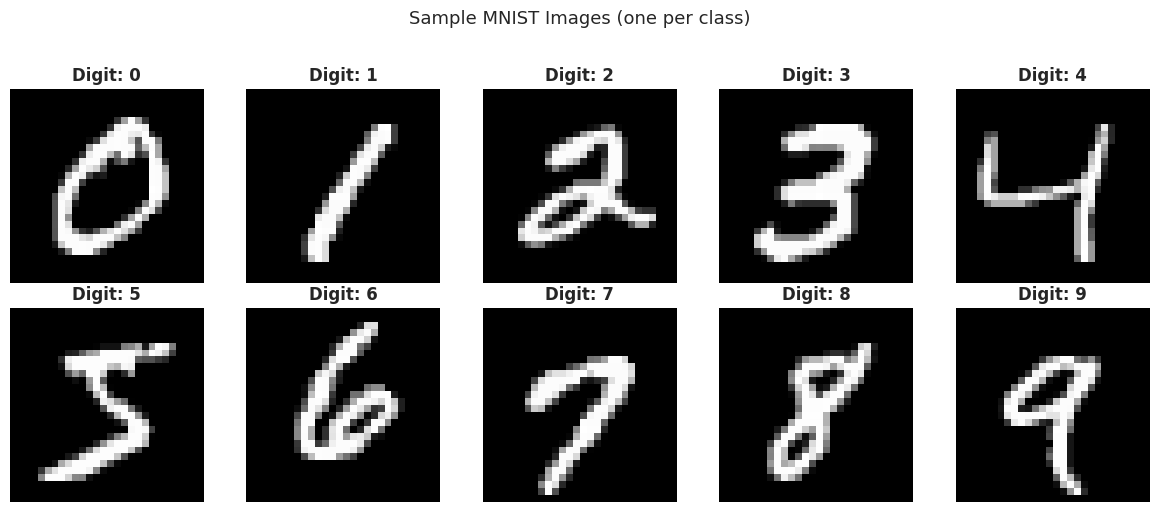

In [54]:

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for digit in range(10):
    idx = np.where(y_mnist_train == digit)[0][0]
    ax  = axes[digit // 5][digit % 5]
    ax.imshow(X_mnist_train[idx], cmap='gray')
    ax.set_title(f'Digit: {digit}', fontweight='bold')
    ax.axis('off')
plt.suptitle('Sample MNIST Images (one per class)', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

In [55]:

mlp_mnist = keras.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
], name='MLP_MNIST')

mlp_mnist.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
mlp_mnist.summary()

mlp_mnist_hist = mlp_mnist.fit(
    X_mnist_train, y_mnist_train,
    validation_data=(X_mnist_test, y_mnist_test),
    epochs=5, batch_size=64, verbose=1
)

mlp_mnist_acc = mlp_mnist.evaluate(X_mnist_test, y_mnist_test, verbose=0)[1]
print(f'\nMLP Baseline Test Accuracy: {mlp_mnist_acc:.4f}')

Model: "MLP_MNIST"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,890 (198.79 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8232 - loss: 0.6597 - val_accuracy: 0.8700 - val_loss: 0.4538
Epoch 2/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9173 - loss: 0.2987 - val_accuracy: 0.8945 - val_loss: 0.3663
Epoch 3/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9358 - loss: 0.2364 - val_accuracy: 0.9050 - val_loss: 0.3225
Epoch 4/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9460 - loss: 0.1984 - val_accuracy: 0.9105 - val_loss: 0.2967
Epoch 5/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9539 - loss: 0.1704 - val_accuracy: 0.9115 - val_loss: 0.2798

MLP Baseline Test Accuracy: 0.9115


## D2 · Lightweight CNN

In [56]:

data_augmentation = keras.Sequential([
    layers.RandomRotation(0.05),
    layers.RandomTranslation(height_factor=0.05, width_factor=0.05),
    layers.RandomZoom(0.05),
], name='augmentation')


cnn_input = layers.Input(shape=(28, 28, 1))
x = data_augmentation(cnn_input)
x = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(x)
x = layers.MaxPooling2D((2, 2))(x)
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = layers.MaxPooling2D((2, 2))(x)
x = layers.Flatten()(x)
x = layers.Dense(64, activation='relu')(x)
x = layers.Dropout(0.3)(x)
cnn_output = layers.Dense(10, activation='softmax')(x)

cnn_model = keras.Model(inputs=cnn_input, outputs=cnn_output, name='LightCNN')
cnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
cnn_model.summary()

Model: "LightCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_14 (InputLayer)     │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1568)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 64)             │       100,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 105,866 (413.54 KB)

 Trainable params: 105,866 (413.54 KB)

 Non-trainable params: 0 (0.00 B)

In [57]:

cnn_es = callbacks.EarlyStopping(monitor='val_accuracy', patience=5,
                                  restore_best_weights=True)

cnn_hist = cnn_model.fit(
    X_mnist_train_cnn, y_mnist_train_oh,
    validation_data=(X_mnist_test_cnn, y_mnist_test_oh),
    epochs=25, batch_size=64,
    callbacks=[cnn_es], verbose=1
)

cnn_test_loss, cnn_test_acc = cnn_model.evaluate(X_mnist_test_cnn, y_mnist_test_oh, verbose=0)
print(f'CNN Test Accuracy: {cnn_test_acc:.4f}')

Epoch 1/25
188/188 ━━━━━━━━━━━━━━━━━━━━ 12s 50ms/step - accuracy: 0.6897 - loss: 0.9527 - val_accuracy: 0.9145 - val_loss: 0.2833
Epoch 2/25
188/188 ━━━━━━━━━━━━━━━━━━━━ 12s 59ms/step - accuracy: 0.8862 - loss: 0.3728 - val_accuracy: 0.9435 - val_loss: 0.1765
Epoch 3/25
188/188 ━━━━━━━━━━━━━━━━━━━━ 9s 50ms/step - accuracy: 0.9149 - loss: 0.2781 - val_accuracy: 0.9650 - val_loss: 0.1244
Epoch 4/25
188/188 ━━━━━━━━━━━━━━━━━━━━ 9s 47ms/step - accuracy: 0.9319 - loss: 0.2246 - val_accuracy: 0.9630 - val_loss: 0.1084
Epoch 5/25
188/188 ━━━━━━━━━━━━━━━━━━━━ 10s 52ms/step - accuracy: 0.9423 - loss: 0.1993 - val_accuracy: 0.9710 - val_loss: 0.0848
Epoch 6/25
188/188 ━━━━━━━━━━━━━━━━━━━━ 10s 56ms/step - accuracy: 0.9436 - loss: 0.1913 - val_accuracy: 0.9765 - val_loss: 0.0810
Epoch 7/25
188/188 ━━━━━━━━━━━━━━━━━━━━ 9s 48ms/step - accuracy: 0.9519 - loss: 0.1583 - val_accuracy: 0.9750 - val_loss: 0.0795
Epoch 8/25
188/188 ━━━━━━━━━━━━━━━━━━━━ 9s 44ms/step - accuracy: 0.9526 - loss: 0.1482 - val_

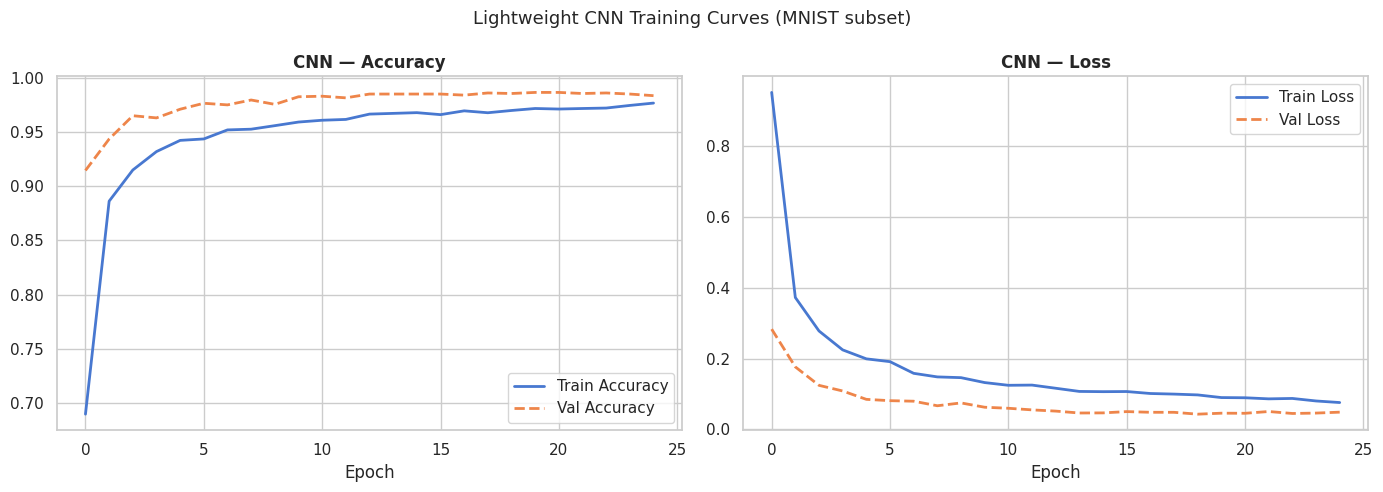

In [58]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, metric, title in zip(axes, ['accuracy', 'loss'], ['Accuracy', 'Loss']):
    ax.plot(cnn_hist.history[metric],          label=f'Train {title}', lw=2)
    ax.plot(cnn_hist.history[f'val_{metric}'], label=f'Val {title}',   lw=2, ls='--')
    ax.set_title(f'CNN — {title}', fontweight='bold')
    ax.set_xlabel('Epoch'); ax.legend()
plt.suptitle('Lightweight CNN Training Curves (MNIST subset)', fontsize=13)
plt.tight_layout(); plt.show()

CNN — Test Metrics
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       175
           1       0.99      1.00      1.00       234
           2       0.99      0.98      0.98       219
           3       0.97      0.99      0.98       207
           4       0.99      1.00      0.99       217
           5       0.97      0.98      0.97       179
           6       0.99      0.99      0.99       178
           7       0.99      0.99      0.99       205
           8       0.99      0.98      0.98       192
           9       0.98      0.97      0.98       194

    accuracy                           0.99      2000
   macro avg       0.99      0.99      0.99      2000
weighted avg       0.99      0.99      0.99      2000

Macro F1: 0.9864


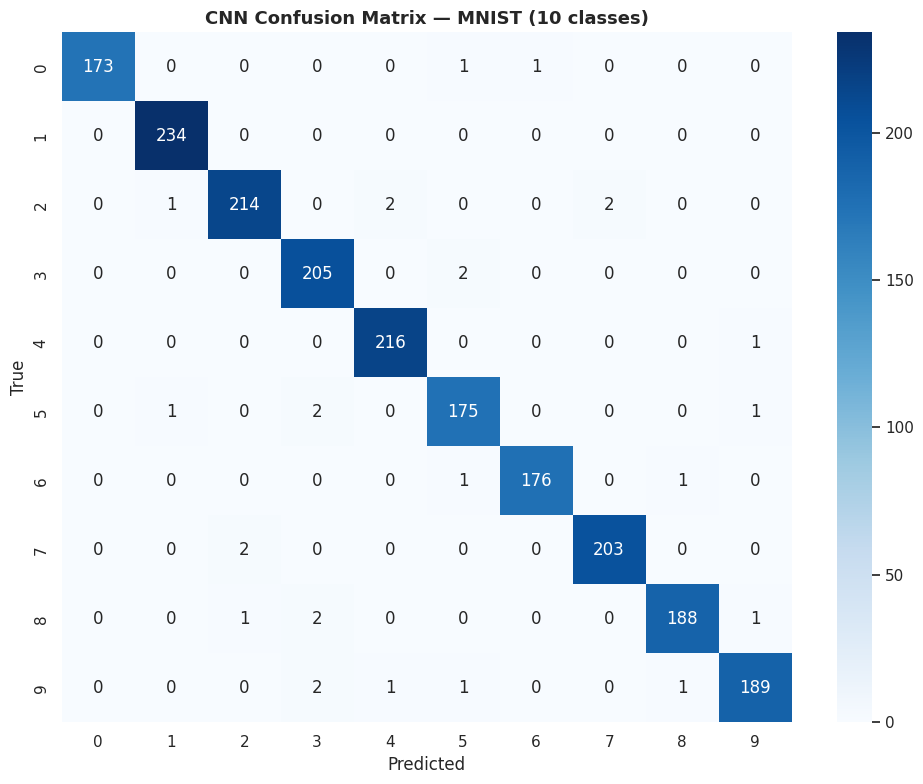


Most confused digit pairs:
  True 8 → Predicted 3  (2 times)
  True 7 → Predicted 2  (2 times)

MLP Baseline Accuracy : 0.9115
CNN Test Accuracy     : 0.9865
CNN surpassed MLP baseline at epoch: 1


In [59]:

y_pred_cnn  = cnn_model.predict(X_mnist_test_cnn, verbose=0).argmax(axis=1)
cnn_macro_f1 = f1_score(y_mnist_test, y_pred_cnn, average='macro')

print('CNN — Test Metrics')
print(classification_report(y_mnist_test, y_pred_cnn))
print(f'Macro F1: {cnn_macro_f1:.4f}')

# Confusion matrix heatmap
cm_cnn = confusion_matrix(y_mnist_test, y_pred_cnn)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=range(10), yticklabels=range(10))
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title('CNN Confusion Matrix — MNIST (10 classes)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

# Most confused pairs
cm_nodiag = cm_cnn.copy(); np.fill_diagonal(cm_nodiag, 0)
confused_pairs = np.dstack(np.unravel_index(np.argsort(cm_nodiag.ravel())[-4:], cm_nodiag.shape))[0]
print('\nMost confused digit pairs:')
for r, c in confused_pairs[::-1][:2]:
    print(f'  True {r} → Predicted {c}  ({cm_nodiag[r, c]} times)')


print(f'\nMLP Baseline Accuracy : {mlp_mnist_acc:.4f}')
print(f'CNN Test Accuracy     : {cnn_test_acc:.4f}')

# Find epoch where CNN surpassed MLP
surpass_epoch = next(
    (i+1 for i, v in enumerate(cnn_hist.history['val_accuracy']) if v >= mlp_mnist_acc),
    'Not reached'
)
print(f'CNN surpassed MLP baseline at epoch: {surpass_epoch}')

## D3 · Visualising What the CNN Learned [4 Marks]

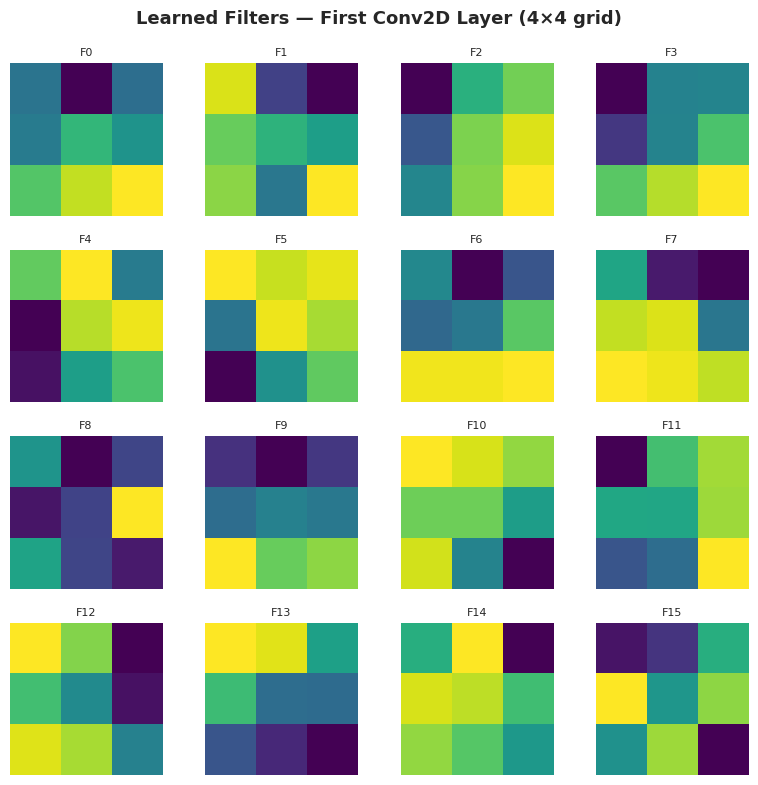

In [60]:

# Find first Conv2D layer
conv1_layer = next(l for l in cnn_model.layers if isinstance(l, layers.Conv2D))
filters = conv1_layer.get_weights()[0]

fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    f = filters[:, :, 0, i]
    f = (f - f.min()) / (f.max() - f.min() + 1e-8)
    ax.imshow(f, cmap='viridis')
    ax.axis('off')
    ax.set_title(f'F{i}', fontsize=8)
plt.suptitle('Learned Filters — First Conv2D Layer (4×4 grid)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()



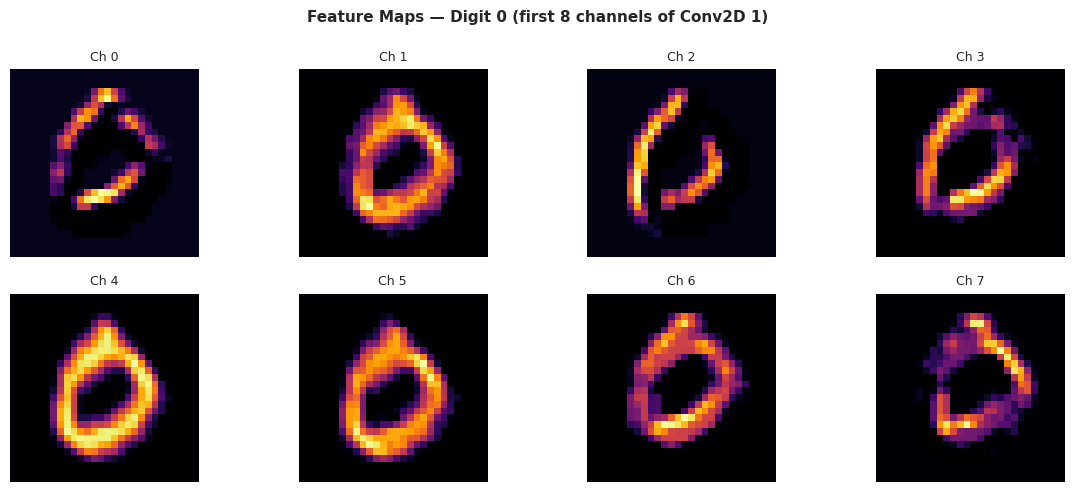

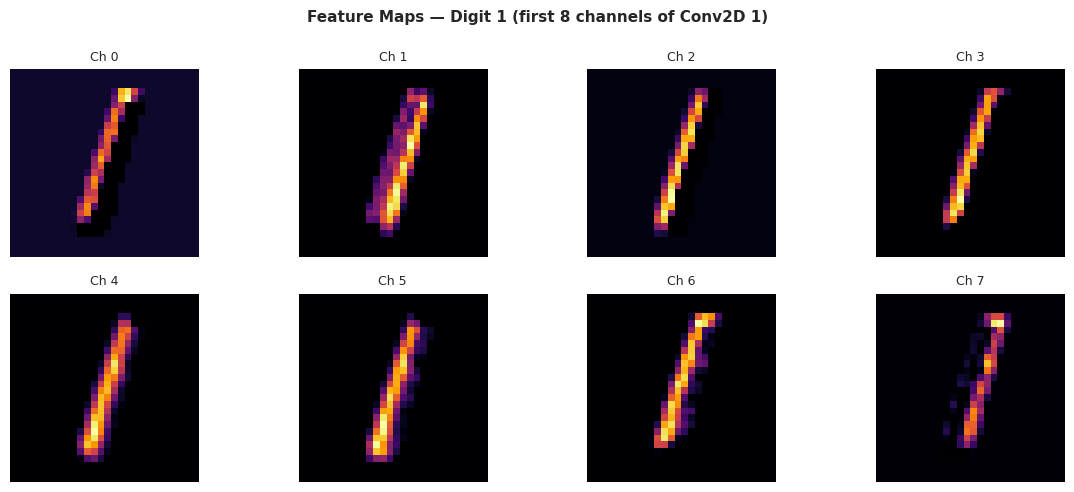

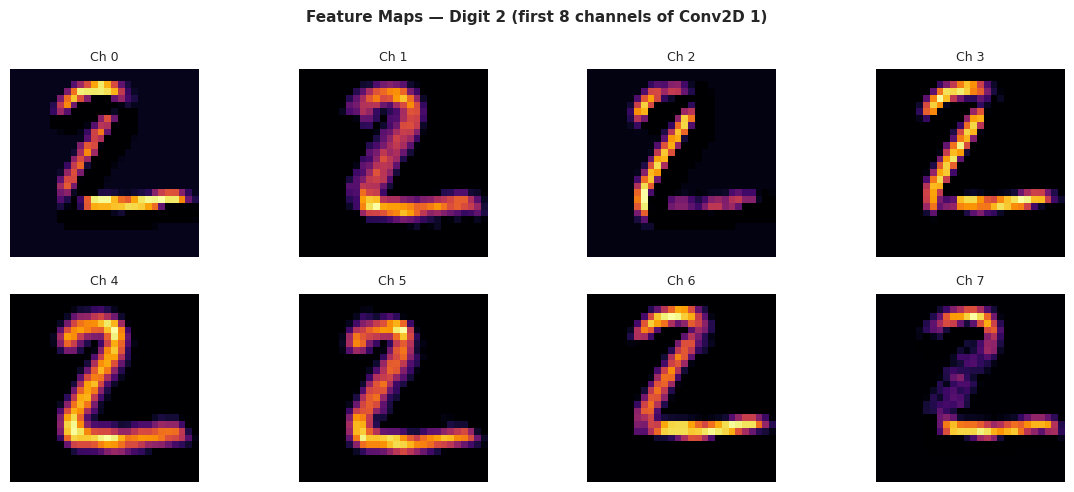

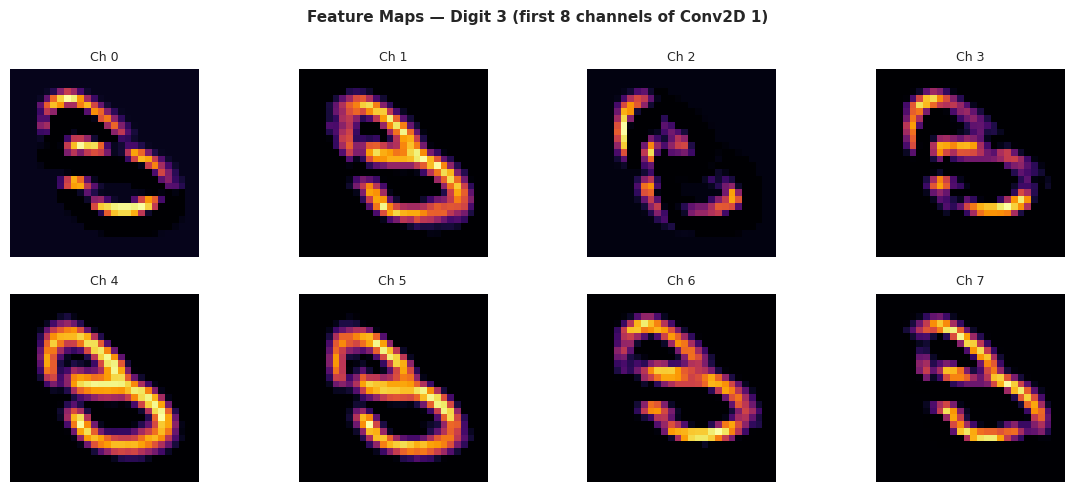

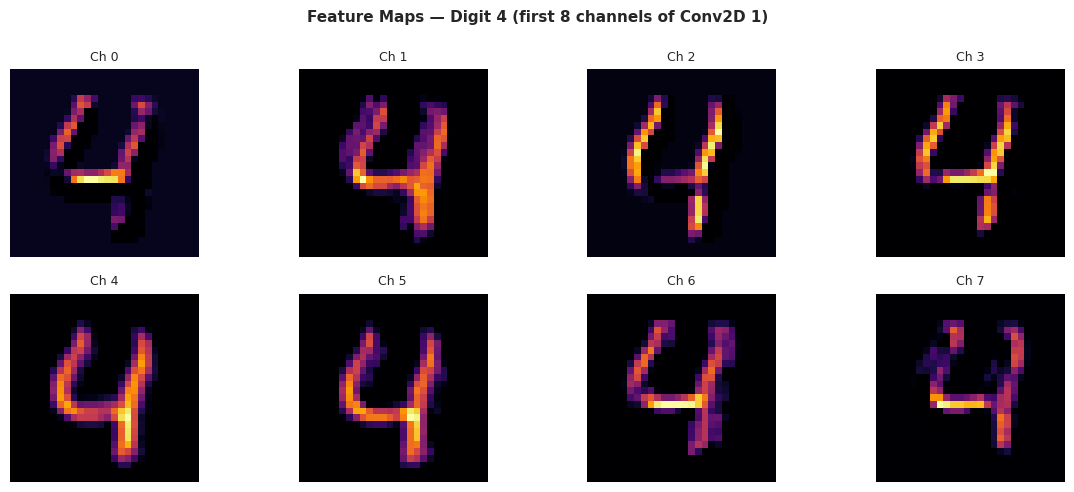

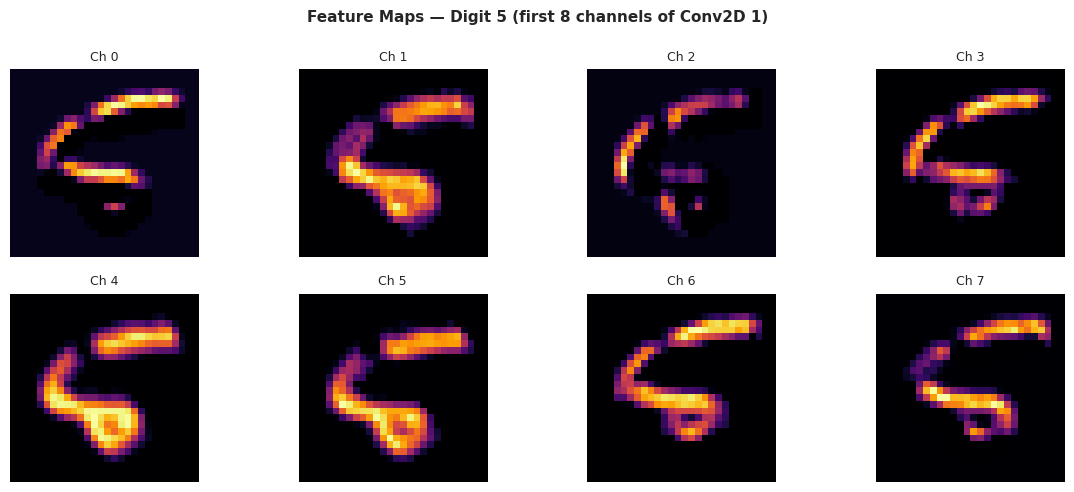

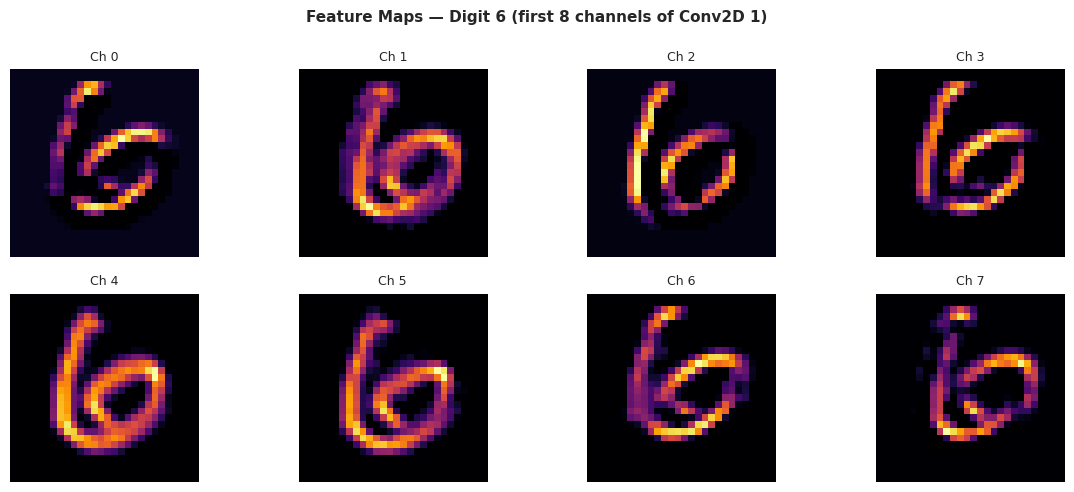

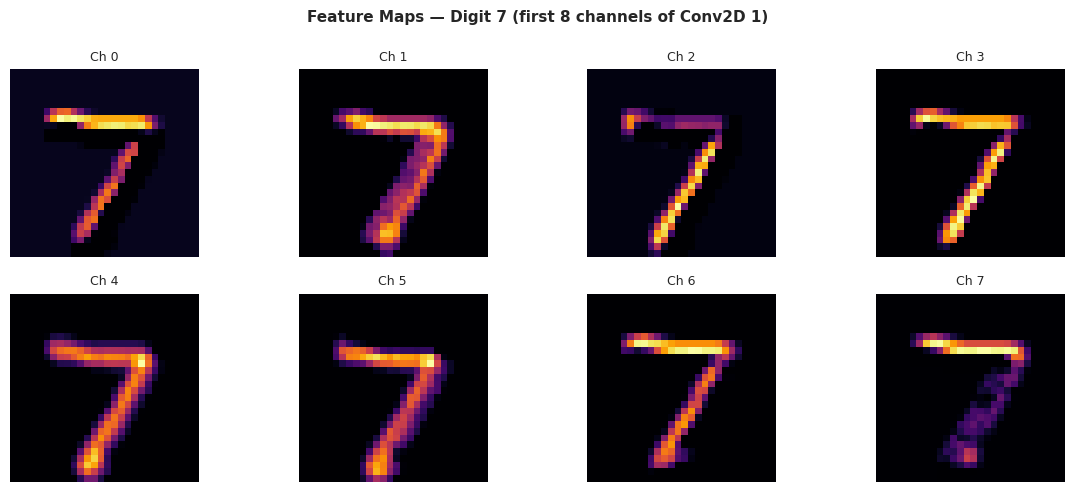

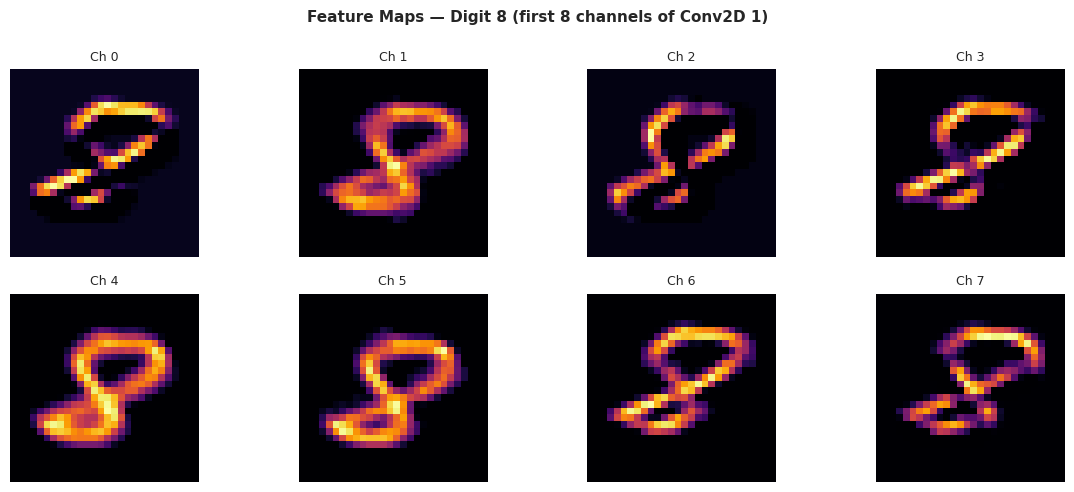

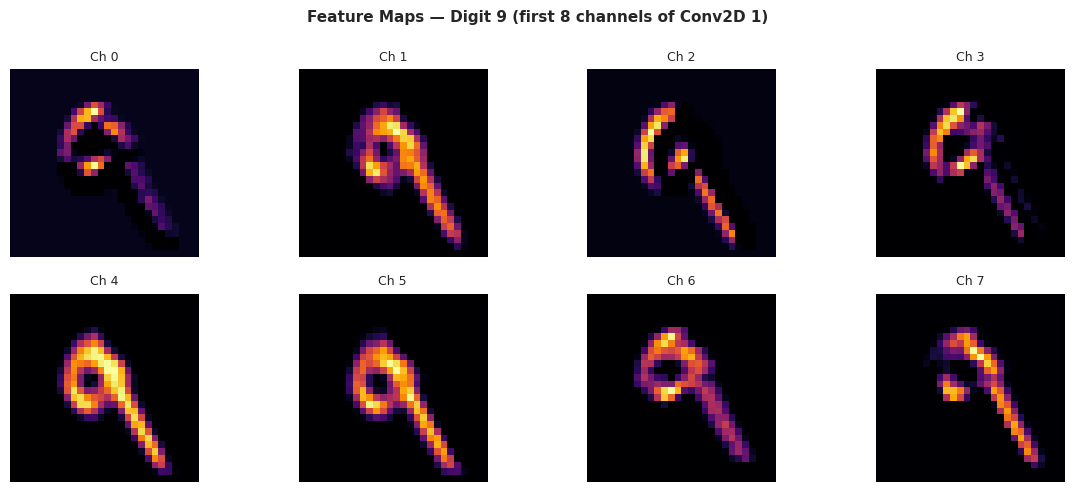

In [61]:

feat_map_model = keras.Model(
    inputs=cnn_model.input,
    outputs=conv1_layer.output
)

for digit in range(10):
    idx  = np.where(y_mnist_test == digit)[0][0]
    img  = X_mnist_test_cnn[idx:idx+1]
    fmap = feat_map_model.predict(img, verbose=0)[0]

    fig, axes = plt.subplots(2, 4, figsize=(12, 5))
    for ch, ax in enumerate(axes.flat[:8]):
        ax.imshow(fmap[:, :, ch], cmap='inferno')
        ax.axis('off')
        ax.set_title(f'Ch {ch}', fontsize=9)

    fig.suptitle(f'Feature Maps — Digit {digit} (first 8 channels of Conv2D 1)',
                 fontsize=11, fontweight='bold')
    plt.tight_layout(); plt.show()




#  PART E — Streamlit Dashboard



In [62]:
import joblib, os

os.makedirs('app', exist_ok=True)

xgb_final.save_model('app/xgb_model.json')

joblib.dump(scaler,               'app/scaler.pkl')
joblib.dump(X_train_enc.columns.tolist(), 'app/feature_names.pkl')


joblib.dump(explainer_xgb,        'app/shap_explainer.pkl')

# Save a real test patient for pre-population
test_patient_raw = X_test_raw.iloc[0].to_dict()
import json
with open('app/sample_patient.json', 'w') as f:
    json.dump(test_patient_raw, f)

print('All model artifacts saved to /app/')
print('Sample patient:', test_patient_raw)
print('True label    :', y_test.iloc[0])

All model artifacts saved to /app/
Sample patient: {'age': 59.0, 'sex': 1.0, 'cp': 3.0, 'trestbps': 138.0, 'chol': 271.0, 'fbs': 0.0, 'restecg': 2.0, 'thalach': 182.0, 'exang': 0.0, 'oldpeak': 0.0, 'slope': 0.0, 'ca': 0.0, 'thal': 1.0}
True label    : 0


In [63]:

app_code = '''
# app.py  —  CardioAI Heart Disease Prediction Dashboard
# Run with: streamlit run app.py

import streamlit as st
import pandas as pd
import numpy as np
import joblib, json, os
import xgboost as xgb
import shap
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use("Agg")

# ── Page config ───────────────────────────────────────────────────────────────
st.set_page_config(page_title="CardioAI Dashboard", page_icon="❤️", layout="wide")
st.title("❤️ CardioAI — Heart Disease Risk Prediction")
st.markdown("*Clinical Decision Support · DS-3002 Assignment #4*")
st.markdown("---")

# ── Load artifacts ────────────────────────────────────────────────────────────
BASE = os.path.dirname(__file__)

@st.cache_resource
def load_artifacts():
    model = xgb.XGBClassifier()
    model.load_model(os.path.join(BASE, "xgb_model.json"))
    scaler        = joblib.load(os.path.join(BASE, "scaler.pkl"))
    feature_names = joblib.load(os.path.join(BASE, "feature_names.pkl"))
    explainer     = joblib.load(os.path.join(BASE, "shap_explainer.pkl"))
    with open(os.path.join(BASE, "sample_patient.json")) as f:
        sample = json.load(f)
    return model, scaler, feature_names, explainer, sample

model, scaler, feature_names, explainer, sample = load_artifacts()

CONT_COLS = ["age", "trestbps", "chol", "thalach", "oldpeak", "ca"]
CAT_COLS  = ["cp", "restecg", "slope", "thal"]

# ── Sidebar: input form ───────────────────────────────────────────────────────
st.sidebar.header("📋 Patient Clinical Data")
st.sidebar.markdown("*Pre-populated with a real test patient.*")

def num_input(label, key, min_v, max_v, default, step=1, fmt="%d"):
    return st.sidebar.number_input(label, min_value=float(min_v), max_value=float(max_v),
                                   value=float(default), step=float(step), format=fmt,
                                   key=key)

age     = num_input("Age (20–80 years)",                      "age",     20,  80, int(sample["age"]))
sex     = st.sidebar.selectbox("Sex",                         [0, 1],    index=int(sample["sex"]),
                               format_func=lambda x: "Male (1)" if x else "Female (0)")
cp      = st.sidebar.selectbox("Chest Pain Type (0–3)",        [0,1,2,3], index=int(sample["cp"]),
                               format_func=lambda x: f"{x}: {['Typical angina','Atypical','Non-anginal','Asymptomatic'][x]}")
trestbps= num_input("Resting BP (94–200 mmHg)",               "tbps",    94, 200, int(sample["trestbps"]))
chol    = num_input("Cholesterol (126–564 mg/dl)",            "chol",   126, 564, int(sample["chol"]))
fbs     = st.sidebar.selectbox("Fasting Blood Sugar >120 mg/dl", [0,1],  index=int(sample["fbs"]),
                               format_func=lambda x: "Yes (1)" if x else "No (0)")
restecg = st.sidebar.selectbox("Resting ECG (0–2)",            [0,1,2],  index=int(sample["restecg"]),
                               format_func=lambda x: f"{x}: {['Normal','ST-T abnorm','LV hypertrophy'][x]}")
thalach = num_input("Max Heart Rate (71–202 bpm)",             "thal_hr", 71, 202, int(sample["thalach"]))
exang   = st.sidebar.selectbox("Exercise-induced Angina",      [0,1],    index=int(sample["exang"]),
                               format_func=lambda x: "Yes (1)" if x else "No (0)")
oldpeak = num_input("ST Depression (0.0–6.2)",                 "oldpeak", 0, 6.2, float(sample["oldpeak"]), 0.1, "%.1f")
slope   = st.sidebar.selectbox("Slope of ST Segment (0–2)",    [0,1,2],  index=int(sample["slope"]),
                               format_func=lambda x: f"{x}: {['Upsloping','Flat','Downsloping'][x]}")
ca      = num_input("Major Vessels (0–3)",                     "ca",      0,   3, int(sample["ca"]))
thal    = st.sidebar.selectbox("Thalassemia (1–3)",             [1,2,3],  index=int(sample["thal"])-1,
                               format_func=lambda x: f"{x}: {['Normal','Fixed defect','Reversible defect'][x-1]}")

predict_btn = st.sidebar.button("🔍 Predict", use_container_width=True)

# ── Preprocessing helper ─────────────────────────────────────────────────────
def preprocess_patient(inputs: dict):
    row = pd.DataFrame([inputs])
    row = pd.get_dummies(row, columns=CAT_COLS)
    row = row.reindex(columns=feature_names, fill_value=0)
    row[CONT_COLS] = scaler.transform(row[CONT_COLS])
    return row

# ── Results panel ─────────────────────────────────────────────────────────────
if predict_btn:
    patient = dict(age=age, sex=sex, cp=cp, trestbps=trestbps, chol=chol,
                   fbs=fbs, restecg=restecg, thalach=thalach, exang=exang,
                   oldpeak=oldpeak, slope=slope, ca=ca, thal=thal)
    X_input = preprocess_patient(patient)

    proba   = model.predict_proba(X_input)[0][1]
    pred    = int(proba >= 0.5)

    col1, col2 = st.columns([1, 2])

    with col1:
        if pred == 1:
            st.error(f"### 🔴 Disease Present")
            st.markdown(f"**Confidence:** {proba*100:.1f}%")
        else:
            st.success(f"### 🟢 No Disease Detected")
            st.markdown(f"**Confidence:** {(1-proba)*100:.1f}%")

        st.progress(float(proba))
        st.metric("Risk Score", f"{proba*100:.1f}%")

    # SHAP top-3 features
    shap_vals = explainer.shap_values(X_input)[0]
    shap_series = pd.Series(np.abs(shap_vals), index=feature_names)
    top3 = shap_series.nlargest(3)

    with col2:
        st.markdown("#### 🔑 Top 3 Features Driving Prediction")
        fig, ax = plt.subplots(figsize=(6, 2.5))
        colors = ["tomato" if shap_vals[feature_names.index(f)] > 0 else "steelblue"
                  for f in top3.index]
        ax.barh(top3.index[::-1], top3.values[::-1], color=colors[::-1], edgecolor="white")
        ax.set_xlabel("|SHAP value|")
        ax.set_title("Feature Impact (red = increases risk)", fontsize=10)
        plt.tight_layout()
        st.pyplot(fig)
        plt.close()

    st.markdown("---")
    feat_display = ", ".join([f"**{f}** ({v:.2f})" for f, v in top3.items()])
    if pred == 1:
        st.warning(
            f"**Clinical Note for nursing staff:** This patient shows elevated cardiac risk. "
            f"The strongest contributing factors are {feat_display}. "
            f"Low maximum heart rate and elevated ST depression are hallmark signs of myocardial ischaemia. "
            f"Referral to a cardiologist for further evaluation is strongly recommended."
        )
    else:
        st.info(
            f"**Clinical Note for nursing staff:** Current indicators suggest low cardiac risk. "
            f"Key features assessed: {feat_display}. "
            f"Continue routine monitoring and standard cardiovascular risk-factor counselling."
        )

else:
    st.info("👈 Enter patient values in the sidebar and click **Predict** to see results.")
    st.markdown("""
    ### About This Dashboard
    - **Model:** XGBoost with SHAP explanations
    - **Dataset:** UCI Heart Disease (Cleveland, n=297)
    - **Purpose:** Clinical decision support for community hospital cardiologists
    - **Note:** This is a research prototype — not a certified medical device.
    """)
'''

with open('app/app.py', 'w') as f:
    f.write(app_code.strip())

# Write requirements.txt
req = '''streamlit>=1.32.0
xgboost>=2.0.0
shap>=0.45.0
scikit-learn>=1.4.0
imbalanced-learn>=0.12.0
pandas>=2.0.0
numpy>=1.26.0
matplotlib>=3.8.0
seaborn>=0.13.0
joblib>=1.3.0
tensorflow>=2.15.0
scipy>=1.12.0
'''
with open('app/requirements.txt', 'w') as f:
    f.write(req)

print('app/app.py written.')
print('app/requirements.txt written.')
print('\nTo run the dashboard: streamlit run app/app.py')

app/app.py written.
app/requirements.txt written.

To run the dashboard: streamlit run app/app.py


---
# 📊 Final Summary Dashboard

In [64]:
summary = pd.DataFrame([
    {'Model': 'SLP',          'Accuracy': round(slp_acc,4),  'Macro F1': round(slp_f1,4),  'AUC-ROC': round(slp_auc,4)},
    {'Model': 'MLP',          'Accuracy': round(mlp_acc,4),  'Macro F1': round(mlp_f1,4),  'AUC-ROC': round(mlp_auc,4)},
    {'Model': 'Random Forest','Accuracy': round(rf_acc,4),   'Macro F1': round(rf_f1,4),   'AUC-ROC': round(rf_auc,4)},
    {'Model': 'XGBoost',      'Accuracy': round(xgb_acc,4),  'Macro F1': round(xgb_f1,4),  'AUC-ROC': round(xgb_auc,4)},
    {'Model': 'CNN (MNIST)',   'Accuracy': round(cnn_test_acc,4), 'Macro F1': round(cnn_macro_f1,4), 'AUC-ROC': 'N/A'},
])

print('=== FINAL MODEL SUMMARY TABLE ===')
display(summary)

print('''
Assignment complete.
Submission checklist:
  [x] Heart Disease preprocessing (Pre 1–6)
  [x] Part A: K-Means, Hierarchical Clustering, PCA, t-SNE
  [x] Part B: Random Forest, XGBoost, ROC comparison
  [x] Part C: SLP, MLP (3 architectures), Ablation study
  [x] Part D: MNIST MLP baseline, CNN, filter/feature-map viz
  [x] Part E: Streamlit dashboard (app/app.py + model artifacts)
''')

=== FINAL MODEL SUMMARY TABLE ===


,Model,Accuracy,Macro F1,AUC-ROC
0,SLP,0.8852,0.8851,0.9589
1,MLP,0.8852,0.8851,0.9567
2,Random Forest,0.9016,0.9016,0.9443
3,XGBoost,0.8852,0.8852,0.9481
4,CNN (MNIST),0.9865,0.9864,N/A



Assignment complete.
Submission checklist:
  [x] Heart Disease preprocessing (Pre 1–6)
  [x] Part A: K-Means, Hierarchical Clustering, PCA, t-SNE
  [x] Part B: Random Forest, XGBoost, ROC comparison
  [x] Part C: SLP, MLP (3 architectures), Ablation study
  [x] Part D: MNIST MLP baseline, CNN, filter/feature-map viz
  [x] Part E: Streamlit dashboard (app/app.py + model artifacts)

